In [1]:
%load_ext autoreload 
#hopefully this will reload the modules when they are changed specifically when i change the plotting modules
%autoreload 2

In [2]:
from myproject import GalaxyGroup, Subhalo, ListGalaxyGroup, AstroPlotter
import h5py as h5
import numpy as np

In [7]:
sim = 'TNG300-1'
snapshot = 'z0p0'
scratchDataDirc = f'/scratch/poulin.al/lopsided/{sim}/{snapshot}/data'
scratchPlotDirc = f'/scratch/poulin.al/lopsided/{sim}/{snapshot}/plots'
localDataDirc = f'/Users/alexpoulin/Library/CloudStorage/OneDrive-NortheasternUniversity/TGB–Data'


In [8]:
generalRewrite = False

## load data from hdf5 file


In [11]:
data_file = scratchDataDirc + f'/galaxy_data_{sim}.hdf5'
# data_file = localDataDirc + f'/galaxy_data_{sim}.hdf5'
with h5.File(data_file, 'r') as f:
    list_of_galaxy_groups = ListGalaxyGroup.from_hdf5(f)
print(f'Loaded galaxy data from {data_file}')

Progress: 3732/3732
Loaded 3732 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1.hdf5


In [ ]:
# print(f"len filtered: {len(filtered_galaxy_groups)}")
filtered_list_of_galaxy_groups = list_of_galaxy_groups.getFilterSubhalos(minGGMass=1e14)

total to process: 3732


In [ ]:
#check the number of galaxy groups loaded
print(f'Number of galaxy groups loaded: {filtered_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f"Number of subhalos in GG 0: {filtered_list_of_galaxy_groups.getGalaxyGroupI(0).getNumSubhalos()}")
print(f"Number of subhalos in GG 10: {filtered_list_of_galaxy_groups.getGalaxyGroupI(10).getNumSubhalos()}")
print(f' Range of satellites: {filtered_list_of_galaxy_groups.getRangeOfNumSubhalos()}')

Number of galaxy groups loaded: 280
Number of subhalos in GG 0: 598
Number of subhalos in GG 10: 98
 Range of satellites: (31, 597)


## Make plots for Pairwise Polar Differences

In [8]:
list_pairwise_polar_differences = filtered_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar', rewrite=generalRewrite)

Total Galaxy Groups to process: 280 with pairs : 2068402
Resuming from existing temp file: pairwise_differences_280.hdf5

Final save after processing all galaxy groups.
Accumulating results from saved batches...


In [9]:
# polar_bin_centers, pairwise_polar_differences = list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=False, tempSaveDir=localDataDirc)
pairwise_polar_differences_binned, polar_bin_centers, pairwise_polar_errorbars = ListGalaxyGroup.get_histogram_bins(list_pairwise_polar_differences, bins = np.arange(0, 185, 10), errorbarType='bootstrap')
print('Computed pairwise polar differences between satellite galaxies.')
# print(polar_bin_centers)
#may need:
# #check and flatten any tuples
        # for galaxyPairwiseGroup in self.list_pairwise_differences:
        #     for pair in galaxyPairwiseGroup:
        #         # print(f"pair: {pair, type(pair)}")
        #         if isinstance(pair, tuple):
        #             print(f"Warning.... flattening tuple pair: {pair, type(pair)}")
        #             return
        #             pairwise_differences_flatten.extend(pair)
        #         else:
        #             pairwise_differences_flatten.append(pair)

Bootstrapping... Current std of bootstrap means: nan, Original mean: 0.0056

/home/poulin.al/.conda/envs/myenv/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/poulin.al/.conda/envs/myenv/lib/python3.13/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/poulin.al/.conda/envs/myenv/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Computed pairwise polar differences between satellite galaxies.


warning ax is none


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:232: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/pairwise_polar/pairwise_polar_difference_TNG300-1.png


(<Figure size 600x450 with 1 Axes>,
 <Axes: title={'center': 'Probability Pairwise Polar Difference Distribution for TNG300-1'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>)

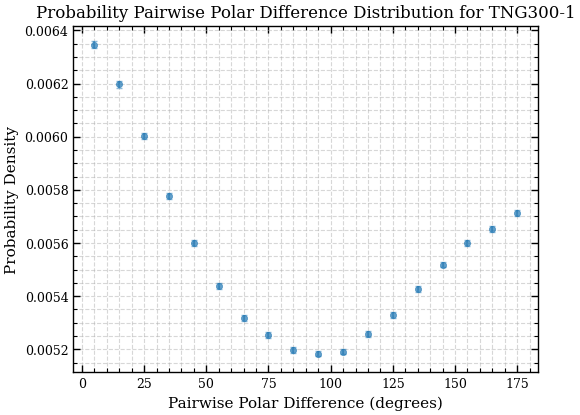

In [10]:
prob_polar_plotter = AstroPlotter()
prob_polar_plotter.scatter_plot(
    polar_bin_centers, 
    pairwise_polar_differences_binned,
    errorBars = pairwise_polar_errorbars,
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for {sim}',
    # ylim = (0, 0.01),
    output_filename=scratchPlotDirc + f'/pairwise_polar/pairwise_polar_difference_{sim}.png',
    grid=True,
)

In [11]:
# save bin centers and probabilities to text file
output_data_file = scratchDataDirc + f'/pairwise_polar/pairwise_polar_difference_{sim}.txt'
# print(f"data to be saved: {np.column_stack((polar_bin_centers, pairwise_polar_differences))}")
np.savetxt(output_data_file, np.column_stack((polar_bin_centers, pairwise_polar_differences_binned)), header='Pairwise Polar Difference (degrees)    Probability Density')

## Make plots for Mean Resultant Length (MRL) directionality

In [12]:
MRL_values = filtered_list_of_galaxy_groups.compute_probablity_distribution_of_MRL_directionality(parallelize=False, tempSaveDir=f'{scratchDataDirc}/MRL_directionality', rewrite=True)#rewrite=generalRewrite)

Resuming from existing temp file: MRL_values_280.hdf5
final: [np.float64(0.07055262092751405), np.float64(0.06882863379814345), np.float64(0.0791280534930706)]



Intermediate save after processing 100 galaxy groups.
Progress: Processing Galaxy Group 200 / 280 with 169 satellites
Intermediate save after processing 200 galaxy groups.
Progress: Processing Galaxy Group 280 / 280 with 58 satellitess
Final save after processing all galaxy groups.


In [13]:
print(len(filtered_list_of_galaxy_groups.MRL_values))

840


In [14]:
MRL_directionality, MRL_bin_centers, MRL_errorbars = filtered_list_of_galaxy_groups.get_histogram_bins(MRL_values, binsize=0.05, binLow=0, binHigh=1, errorbarType='poisson')

warning ax is none
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/MRL/MRL_directionality_TNG300-1.png


(<Figure size 600x450 with 1 Axes>,
 <Axes: title={'center': 'Probability MRL Directionality Distribution for TNG300-1'}, xlabel='MRL Directionality', ylabel='Probability Density'>)

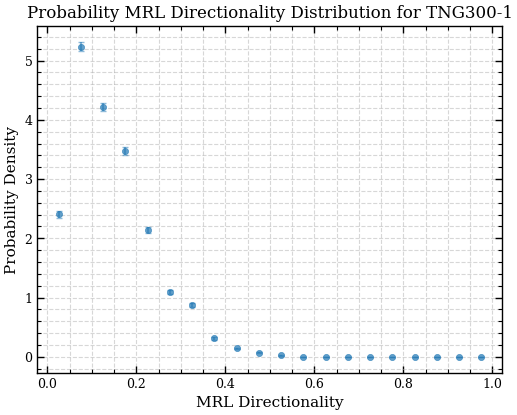

In [15]:
prob_MRL_plotter = AstroPlotter()
prob_MRL_plotter.scatter_plot(
    MRL_bin_centers, 
    MRL_directionality,
    errorBars = MRL_errorbars,
    xlabel='MRL Directionality',
    ylabel='Probability Density',
    title=f'Probability MRL Directionality Distribution for {sim}',
    # ylim=(0,4)
    output_filename=scratchPlotDirc + f'/MRL/MRL_directionality_{sim}.png',
    grid=True
)

In [16]:
#save bin centers and probabilities to text file
output_data_file_MRL = scratchDataDirc + f'/MRL_directionality/MRL_directionality_{sim}.txt'
# print(f"data to be saved: {np.column_stack((MRL_bin_centers, MRL_directionality))}")
np.savetxt(output_data_file_MRL, np.column_stack((MRL_bin_centers, MRL_directionality)), header='MRL Directionality    Probability Density')

In [17]:
#save bin MRL values to text file
output_data_file_MRL = scratchDataDirc + f'/MRL_directionality/MRL_directionality_RAW_{sim}.txt'
# print(f"data to be saved: {np.vstack(filtered_list_of_galaxy_groups.MRL_values)}")
np.savetxt(output_data_file_MRL, np.vstack(filtered_list_of_galaxy_groups.MRL_values), header='MRL Directionality')

## make plots for red vs blue galaxies

In [18]:
filtered_red_list_of_galaxy_groups = filtered_list_of_galaxy_groups.getFilterSubhalos(redGalaxies=True)
print(f'Number of galaxy groups with only red satellites: {filtered_red_list_of_galaxy_groups.getRangeOfNumSubhalos()}')

filtered_blue_list_of_galaxy_groups = filtered_list_of_galaxy_groups.getFilterSubhalos(blueGalaxies=True)
print(f'Number of galaxy groups with only blue satellites: {filtered_blue_list_of_galaxy_groups.getRangeOfNumSubhalos()}')


list_pairwise_polar_differences_red = filtered_red_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_color/pairwise_polar_red', rewrite=generalRewrite)
list_pairwise_polar_differences_blue = filtered_blue_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_color/pairwise_polar_blue', rewrite=generalRewrite)


total to process: 280
Number of galaxy groups with only red satellites: (24, 507)
total to process: 280
Number of galaxy groups with only blue satellites: (2, 134)
Total Galaxy Groups to process: 280 with pairs : 1274813
Resuming from existing temp file: pairwise_differences_280.hdf5

Final save after processing all galaxy groups.
Accumulating results from saved batches...
Total Galaxy Groups to process: 280 with pairs : 106639
Resuming from existing temp file: pairwise_differences_280.hdf5

Final save after processing all galaxy groups.
Accumulating results from saved batches...


In [29]:
pairwise_polar_differences_red, polar_bin_centers_red, pairwise_polar_red_errorbars = ListGalaxyGroup.get_histogram_bins(list_pairwise_polar_differences_red, bins = np.arange(0, 185, 10), errorbarType='bootstrap')
pairwise_polar_differences_blue, polar_bin_centers_blue, pairwise_polar_blue_errorbars = ListGalaxyGroup.get_histogram_bins(list_pairwise_polar_differences_blue, bins = np.arange(0, 185, 10), errorbarType='bootstrap')

Bootstrapping... Current std of bootstrap means: nan, Original mean: 0.0056

/home/poulin.al/.conda/envs/myenv/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/poulin.al/.conda/envs/myenv/lib/python3.13/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/poulin.al/.conda/envs/myenv/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Bootstrapping... Current std of bootstrap means: nan, Original mean: 0.0056

Computed pairwise polar differences between red and blue satellite galaxies.


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:232: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/pairwise_polar/pairwise_polar_difference_red_blue_TNG300-1.png


(<Figure size 600x450 with 1 Axes>,
 <Axes: title={'center': 'Probability Pairwise Polar Difference Distribution for Red and Blue Satellites in TNG300-1'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>)

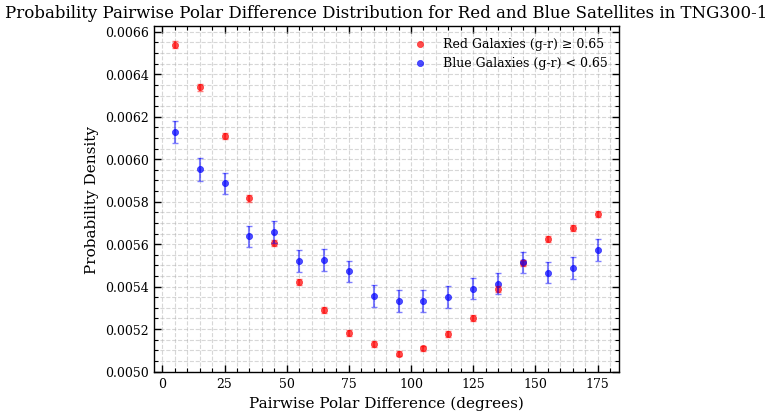

In [30]:
print('Computed pairwise polar differences between red and blue satellite galaxies.')
prob_polar_red_blue_plotter = AstroPlotter()
prob_polar_red_blue_fig, prob_polar_red_blue_ax = prob_polar_red_blue_plotter.create_figure()
prob_polar_red_blue_plotter.scatter_plot(
    polar_bin_centers_red, 
    pairwise_polar_differences_red,
    ax=prob_polar_red_blue_ax, # Use the same axis for overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for Red and Blue Satellites in {sim}',
    # ylim = (0, 0.01),
    c=['red'],
    errorBars = pairwise_polar_red_errorbars,
    label = "Red Galaxies (g-r) ≥ 0.65",
    output_filename=None,  # Disable saving for combined plot
    grid=True,
)
prob_polar_red_blue_plotter.scatter_plot(
    polar_bin_centers_blue, 
    pairwise_polar_differences_blue,
    ax=prob_polar_red_blue_ax,  # Use the same axis for overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for Red and Blue Satellites in {sim}',
    # ylim = (0, 0.01),
    c=['blue'],
    errorBars = pairwise_polar_blue_errorbars,
    label = "Blue Galaxies (g-r) < 0.65",
    include_legend=True,
    output_filename=scratchPlotDirc + f'/pairwise_polar/pairwise_polar_difference_red_blue_{sim}.png',
    grid=True,
)

In [31]:
# save as txt file
output_data_file = scratchDataDirc + f'/pairwise_polar_color/pairwise_polar_color_difference_{sim}.txt'
print(f"data to be saved: {np.column_stack((polar_bin_centers_red, pairwise_polar_differences_red, pairwise_polar_differences_blue))}")
np.savetxt(output_data_file, np.column_stack((polar_bin_centers_red, pairwise_polar_differences_red, pairwise_polar_differences_blue)), header='Pairwise Polar Difference (degrees)    Probability Density (Red)    Probability Density (Blue)')

data to be saved: [[5.00000000e+00 6.53907745e-03 6.12831090e-03]
 [1.50000000e+01 6.33831735e-03 5.95313242e-03]
 [2.50000000e+01 6.10792904e-03 5.88560552e-03]
 [3.50000000e+01 5.81580531e-03 5.63604958e-03]
 [4.50000000e+01 5.60632868e-03 5.65806922e-03]
 [5.50000000e+01 5.42156222e-03 5.52105812e-03]
 [6.50000000e+01 5.28973469e-03 5.52497272e-03]
 [7.50000000e+01 5.18341700e-03 5.47310423e-03]
 [8.50000000e+01 5.12743928e-03 5.35517682e-03]
 [9.50000000e+01 5.08493620e-03 5.33364650e-03]
 [1.05000000e+02 5.10884668e-03 5.33217853e-03]
 [1.15000000e+02 5.17721947e-03 5.35126221e-03]
 [1.25000000e+02 5.25334917e-03 5.39089757e-03]
 [1.35000000e+02 5.38937503e-03 5.41340654e-03]
 [1.45000000e+02 5.51196624e-03 5.51420756e-03]
 [1.55000000e+02 5.62404163e-03 5.46625368e-03]
 [1.65000000e+02 5.67746037e-03 5.48925197e-03]
 [1.75000000e+02 5.74319421e-03 5.57341593e-03]]


## make plots for 150 vs 50 member galaxies

In [ ]:
filtered_GT150_list_of_galaxy_groups = filtered_list_of_galaxy_groups.getFilterSubhalos(minNumGalaxies=150)
print(f'Number of galaxy groups with more than 150 satellites: {filtered_GT150_list_of_galaxy_groups.getNumGalaxyGroups()}')
filtered_LT50_list_of_galaxy_groups = filtered_list_of_galaxy_groups.getFilterSubhalos(maxNumGalaxies=50)
print(f'Number of galaxy groups with less than 50 satellites: {filtered_LT50_list_of_galaxy_groups.getNumGalaxyGroups()}')

list_pairwise_polar_differences_GT150 = filtered_GT150_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_memberNum/pairwise_polar_GT150', rewrite=generalRewrite)
list_pairwise_polar_differences_LT50 = filtered_LT50_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_memberNum/pairwise_polar_LT50', rewrite=generalRewrite)

In [ ]:
print('Computed pairwise polar differences for galaxy groups with >150 and <50 satellites.')
polar_bin_centers_GT150, pairwise_polar_differences_GT150, pairwise_polar_GT150_errorbars = ListGalaxyGroup.get_histogram_bins(list_pairwise_polar_differences_GT150, bins = np.arange(0, 185, 10), parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_GT150', errorbarType='bootstrap')
polar_bin_centers_LT50, pairwise_polar_differences_LT50, pairwise_polar_LT50_errorbars = ListGalaxyGroup.get_histogram_bins(list_pairwise_polar_differences_LT50, bins = np.arange(0, 185, 10), parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_LT50', errorbarType='bootstrap')

In [ ]:
prob_polar_GT150_LT50_plotter = AstroPlotter()
prob_polar_GT150_LT50_fig, prob_polar_GT150_LT50_ax = prob_polar_GT150_LT50_plotter.create_figure()
prob_polar_GT150_LT50_plotter.scatter_plot(
    polar_bin_centers_GT150, 
    pairwise_polar_differences_GT150,
    errorBars = pairwise_polar_GT150_errorbars,
    ax=prob_polar_GT150_LT50_ax, # Use the same axis for overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for >150 and <50 Satellites in {sim}',
    # ylim = (0, 0.01),
    label="More than 150 members",
    output_filename=None,  # Disable saving for combined plot
    grid=True,
)
prob_polar_GT150_LT50_plotter.scatter_plot(
    polar_bin_centers_LT50, 
    pairwise_polar_differences_LT50,
    errorBars = pairwise_polar_LT50_errorbars,
    ax=prob_polar_GT150_LT50_ax,  # Use the same axis for overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for >150 and <50 Satellites in {sim}',
    # ylim = (0, 0.01),
    label="Less than 50 members",
    include_legend=True,
    output_filename=scratchPlotDirc + f'/pairwise_polar/pairwise_polar_difference_GT150_LT50_{sim}.png',
    grid=True,
)

In [ ]:
# save as text file
output_data_file = scratchDataDirc + f'/pairwise_polar_memberNum/pairwise_polar_memberNum_difference_{sim}.txt'
# print(f"data to be saved: {np.column_stack((polar_bin_centers_LT50, pairwise_polar_differences_LT50, pairwise_polar_differences_GT150))}")
np.savetxt(output_data_file, np.column_stack((polar_bin_centers_LT50, pairwise_polar_differences_LT50, pairwise_polar_differences_GT150)), header='Pairwise Polar Difference (degrees)    Probability Density (<50 Satellites)    Probability Density (>150 Satellites)')

## make plots for <35% vs >65% R200 plots

In [ ]:
filtered_LT35R200_list_of_galaxy_groups = filtered_list_of_galaxy_groups.getFilterSubhalos(withinXPercentR200=[0,0.35])
print(f'Number of galaxy groups with satellites within 35% R200: {filtered_LT35R200_list_of_galaxy_groups.getNumGalaxyGroups()}')
filtered_GT65R200_list_of_galaxy_groups = filtered_list_of_galaxy_groups.getFilterSubhalos(withinXPercentR200=[0.65,1.00])
print(f'Number of galaxy groups with satellites within 65-100% R200: {filtered_GT65R200_list_of_galaxy_groups.getNumGalaxyGroups()}')

list_pairwise_polar_differences_LT35R200 = filtered_LT35R200_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_radius/pairwise_polar_LT35R200', rewrite=generalRewrite)
list_pairwise_polar_differences_GT65R200 = filtered_GT65R200_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_radius/pairwise_polar_GT65R200', rewrite=generalRewrite)

In [ ]:
polar_bin_centers_LT35R200, pairwise_polar_differences_LT35R200, pairwise_polar__LT35R400_errorbars = filtered_LT35R200_list_of_galaxy_groups.get_histogram_bins(list_pairwise_polar_differences_LT35R200, bins = np.arange(0, 185, 10), parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_LT35R200', errorbarType='bootstrap')
polar_bin_centers_GT65R200, pairwise_polar_differences_GT65R200, pairwise_polar_GT65R200_errorbars = filtered_GT65R200_list_of_galaxy_groups.get_histogram_bins(list_pairwise_polar_differences_GT65R200, bins = np.arange(0, 185, 10), parallelize=False, tempSaveDir=f'{scratchDataDirc}/pairwise_polar_GT65R200', errorbarType='bootstrap')

In [ ]:
prob_polar_LT35R200_GT65R200_plotter = AstroPlotter()
prob_polar_LT35R200_GT65R200_fig, prob_polar_LT35R200_GT65R200_ax = prob_polar_LT35R200_GT65R200_plotter.create_figure()
prob_polar_LT35R200_GT65R200_plotter.scatter_plot(
    polar_bin_centers_LT35R200, 
    pairwise_polar_differences_LT35R200,
    errorBars = pairwise_polar__LT35R400_errorbars,
    ax=prob_polar_LT35R200_GT65R200_ax, # Use the same axis for overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for 65%<r<100% R200 and 0%<r<35% R200 in {sim}',
    # ylim = (0, 0.01),
    label="0<r<0.35 R200",
    output_filename=None,  # Disable saving for combined plot
    grid=True,
)
prob_polar_LT35R200_GT65R200_plotter.scatter_plot(
    polar_bin_centers_GT65R200, 
    pairwise_polar_differences_GT65R200,
    errorBars = pairwise_polar_GT65R200_errorbars,
    ax=prob_polar_LT35R200_GT65R200_ax,  # Use the same axis for overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for \n 65%<r<100% R200 and 0%<r<35% R200 in {sim}',
    # ylim = (0, 0.01),
    label="0.65<r<1.00 R200",
    include_legend=True,
    output_filename=scratchPlotDirc + f'/pairwise_polar/pairwise_polar_difference_LT35R200_GT65R200_{sim}.png',
    grid=True,
)

In [ ]:
# save as text file
output_data_file = scratchDataDirc + f'/pairwise_polar_radius/pairwise_polar_radius_difference_{sim}.txt'
# print(f"data to be saved: {np.column_stack((polar_bin_centers_LT35R200, pairwise_polar_differences_LT35R200, pairwise_polar_differences_GT65R200))}")
np.savetxt(output_data_file, np.column_stack((polar_bin_centers_LT35R200, pairwise_polar_differences_LT35R200, pairwise_polar_differences_GT65R200)), header='Pairwise Polar Difference (degrees)    Probability Density (<35% R200)    Probability Density (65-100% R200)')

## check central-FoF distance offests

In [ ]:
#save txt file if most massive != most central
#with lines:
# 1: x_cm of the halo
# 2: y_cm of the halo
# 3: z_cm of the halo
# 4: offset of the "most central galaxy" from the halo center of mass
# 5: ratio of the total masses of the most central and most massive galaxoes
# 6: offset of the most massive galaxy from the halo center of mass

with open(scratchDataDirc + f'/most_massive_vs_most_central/most_massive_vs_most_central_{sim}.txt', 'w') as f:
    f.write('x_cm    y_cm    z_cm    offset_most_central    mass_ratio    offset_most_massive most_massive_r_ratio_r200\n')
    
for galaxy_group in list_of_galaxy_groups.getAllGalaxyGroups():
    if galaxy_group.getMostMassiveSubhalo().getIdx() != galaxy_group.getMostCentralSubhalo().getIdx():
        output_data_file = scratchDataDirc + f'/most_massive_vs_most_central/most_massive_vs_most_central_{sim}.txt'
        with open(output_data_file, 'a') as f:
            x_cm, y_cm, z_cm = galaxy_group.getPos()
            most_central_pos = galaxy_group.getMostCentralSubhalo().getPosition()
            most_massive_pos = galaxy_group.getMostMassiveSubhalo().getPosition()
            offset_most_central = np.linalg.norm(most_central_pos - galaxy_group.getPos())
            offset_most_massive = np.linalg.norm(most_massive_pos - galaxy_group.getPos())
            mass_ratio = galaxy_group.getMostCentralSubhalo().getStellarMass() / galaxy_group.getMostMassiveSubhalo().getStellarMass()
            most_massive_r_ratio_r200 = np.linalg.norm(galaxy_group.getMostMassiveSubhalo().getPosition()) / galaxy_group.getRCrit200()
            f.write(f"{x_cm} {y_cm} {z_cm} {offset_most_central} {mass_ratio} {offset_most_massive} {most_massive_r_ratio_r200} \n")

In [ ]:
#filter to groups with stellar mass < 10^{14} Msun
filtered_gt13_ls14_list_of_galaxy_groups = list_of_galaxy_groups.getFilterSubhalos(maxGGMass=1e14)

In [ ]:
#check the number of galaxy groups loaded
print(f'Number of galaxy groups loaded: {filtered_gt13_ls14_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f"Number of subhalos in GG 0: {filtered_gt13_ls14_list_of_galaxy_groups.getGalaxyGroupI(0).getNumSubhalos()}")
print(f"Number of subhalos in GG 10: {filtered_gt13_ls14_list_of_galaxy_groups.getGalaxyGroupI(10).getNumSubhalos()}")
print(f' Range of satellites: {filtered_gt13_ls14_list_of_galaxy_groups.getRangeOfNumSubhalos()}')

In [ ]:
def getCentral_FoF_distanceOffset(list_of_galaxy_groups : ListGalaxyGroup):
    distanceOffsets = []
    central_positions = []
    FoF_positions = []
    for gg in list_of_galaxy_groups.listGalaxyGroups:
        central_subhalo = gg.getCentralSubhalo()
        fof_center = gg.getPos()
        central_positions.append(central_subhalo.getPosition())
        FoF_positions.append(fof_center)
        
        distanceOffsets.append(np.linalg.norm(central_subhalo.getPosition() - fof_center))
    return np.array(distanceOffsets), np.array(central_positions), np.array(FoF_positions)

In [ ]:
distances_gt13_ls14 = getCentral_FoF_distanceOffset(filtered_gt13_ls14_list_of_galaxy_groups)[0]
print(distances_gt13_ls14)
distances_gt14 = getCentral_FoF_distanceOffset(filtered_list_of_galaxy_groups)[0]


In [ ]:
central_FoF_Plotter = AstroPlotter()
central_FoF_fig, central_FoF_ax = central_FoF_Plotter.create_figure()
central_FoF_Plotter.histogram(
    distances_gt13_ls14,
    bins=60, #np.logspace(np.log10(0.1), np.log10(5000), 60),
    ax = central_FoF_ax,  # Use the same axis for overlay
    xlabel='Distance between Central Subhalo and Galaxy Group Position (kpc)',
    ylabel='Density of Galaxy Groups',
    title=f'Distance between Central Subhalo and Galaxy Group Position for {sim} ($M_{{200}}$<1e14 Msun)',
    label='1e13<$M_{{200}}$<1e14 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=scratchPlotDirc + f'/central_disparities/central_FoF_distance_{sim}_lt14.png',
    percentage=True,
    grid=True,
)
central_FoF_Plotter.histogram(
    distances_gt14,
    bins=60, #np.logspace(np.log10(0.1), np.log10(5000), 60),
    ax = central_FoF_ax,  # Use the same axis for overlay
    xlabel='Distance between Central Subhalo and Galaxy Group Position (kpc)',
    ylabel='Density of Galaxy Groups',
    title=f'Distance between Central Subhalo and Galaxy Group Position for {sim}',
    label='$M_{{200}}$>1e14 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=scratchPlotDirc + f'/central_disparities/central_FoF_distance_{sim}_gt14.png',
    percentage=True,
    grid=True,
)

In [ ]:
#make pairwise polar difference plots for these two mass bins as well
list_pairwise_polar_differences_13_14 = filtered_gt13_ls14_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=False)
list_pairwise_polar_differences_gt14 = filtered_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=False)

In [ ]:
polar_bin_centers_13_14, pairwise_polar_differences_13_14, pairwise_polar_13_14_errorbars = ListGalaxyGroup.get_histogram_bins(list_pairwise_polar_differences_13_14, bins = np.arange(0, 185, 10), parallelize=False, errorbarType='bootstrap')

In [ ]:
polar_bin_centers_gt14, pairwise_polar_differences_gt14, pairwise_polar_gt14_errorbars = ListGalaxyGroup.get_histogram_bins(list_pairwise_polar_differences_gt14, bins = np.arange(0, 185, 10), parallelize=False, errorbarType='bootstrap')

In [ ]:
prob_polar_gt14_lt14_plotter = AstroPlotter()
prob_polar_gt14_lt14_fig, prob_polar_gt14_lt14_ax = prob_polar_gt14_lt14_plotter.create_figure()
prob_polar_gt14_lt14_plotter.scatter_plot(
    polar_bin_centers_13_14, 
    pairwise_polar_differences_13_14,
    errorBars = pairwise_polar_13_14_errorbars,
    ax=prob_polar_gt14_lt14_ax, # Use the same axis for overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for 1e13<$M_{{200}}$<1e14 and $M_{{200}}$>1e14 Msun in {sim}',
    # ylim = (0, 0.01),
    label="1e13<$M_{{200}}$<1e14 Msun",
    output_filename=None,  # Disable saving for combined plot
    grid=True,
)
prob_polar_gt14_lt14_plotter.scatter_plot(
    polar_bin_centers_gt14, 
    pairwise_polar_differences_gt14,
    errorBars = pairwise_polar_gt14_errorbars,
    ax=prob_polar_gt14_lt14_ax,  # Use the same axis for        overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Probability Pairwise Polar Difference Distribution for 1e13<$M_{{200}}$<1e14 and $M_{{200}}$>1e14 Msun in {sim}',
    # ylim = (0, 0.01),
    label="$M_{{200}}$>1e14 Msun",
    include_legend=True,
    output_filename=scratchPlotDirc + f'/pairwise_polar/pairwise_polar_difference_gt14_lt14_{sim}.png',
    grid=True,
)

## prob distribution of mass of five subgroups
13-13.5, 13.5-14, 14-14.5, 14.5-15, >15

In [12]:
#filter to groups with stellar mass 10^{13} < $M_{{200}}$ < 10^{13.5} Msun
filtered_13_13p5_list_of_galaxy_groups = list_of_galaxy_groups.getFilterSubhalos(maxGGMass=5e13, minGGMass=1e13)

#filter to groups with stellar mass 10^{13.5} < $M_{{200}}$ < 10^{14} Msun
filtered_13p5_14_list_of_galaxy_groups = list_of_galaxy_groups.getFilterSubhalos(maxGGMass=1e14, minGGMass=5e13)

#filter to groups with stellar mass 10^{14} < $M_{{200}}$ < 10^{14.5} Msun
filtered_14_14p5_list_of_galaxy_groups = list_of_galaxy_groups.getFilterSubhalos(maxGGMass=5e14, minGGMass=1e14)

#filter to groups with stellar mass 10^{14.5} < $M_{{200}}$ < 10^{15} Msun
filtered_14p5_15_list_of_galaxy_groups = list_of_galaxy_groups.getFilterSubhalos(maxGGMass=1e15, minGGMass=5e14)

#filter to groups with stellar mass $M_{{200}}$ > 10^{15} Msun
filtered_gt15_list_of_galaxy_groups = list_of_galaxy_groups.getFilterSubhalos(minGGMass=1e15)


total to process: 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732


In [40]:
print(f'Number of galaxy groups 13-13.5 loaded: {filtered_13_13p5_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f'Number of galaxy groups 13.5-14 loaded: {filtered_13p5_14_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f'Number of galaxy groups 14-14.5 loaded: {filtered_14_14p5_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f'Number of galaxy groups 14.5-15 loaded: {filtered_14p5_15_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f'Number of galaxy groups >15 loaded: {filtered_gt15_list_of_galaxy_groups.getNumGalaxyGroups()}')

print(f"total number of galaxy groups: {filtered_13_13p5_list_of_galaxy_groups.getNumGalaxyGroups() + filtered_13p5_14_list_of_galaxy_groups.getNumGalaxyGroups() + filtered_14_14p5_list_of_galaxy_groups.getNumGalaxyGroups() + filtered_14p5_15_list_of_galaxy_groups.getNumGalaxyGroups() + filtered_gt15_list_of_galaxy_groups.getNumGalaxyGroups()}")

#print the num of galaxies in each group where the central is not the most massive
num_mostMassiveNotCentral = 0
for gg in filtered_13_13p5_list_of_galaxy_groups.listGalaxyGroups:
    if gg.getMostMassiveSubhalo().getIdx() != gg.getMostCentralSubhalo().getIdx():
        # print(f"GG ID: {gg.getGroupID()}, Num of galaxies: {gg.getNumSubhalos()}")
        num_mostMassiveNotCentral +=1
    else:
        print(gg.getMostMassiveSubhalo().getPosition(), gg.getMostCentralSubhalo().getPosition())
print(f"Number of groups with most massive not central in 13-13.5 bin: {num_mostMassiveNotCentral}")
num_mostMassiveNotCentral = 0
for gg in filtered_13p5_14_list_of_galaxy_groups.listGalaxyGroups:
    if gg.getMostMassiveSubhalo().getIdx() != gg.getMostCentralSubhalo().getIdx():
        # print(f"GG ID: {gg.getGroupID()}, Num of galaxies: {gg.getNumSubhalos()}")
        num_mostMassiveNotCentral +=1
print(f"Number of groups with most massive not central in 13.5-14 bin: {num_mostMassiveNotCentral}")
num_mostMassiveNotCentral = 0
for gg in filtered_14_14p5_list_of_galaxy_groups.listGalaxyGroups:
    if gg.getMostMassiveSubhalo().getIdx() != gg.getMostCentralSubhalo().getIdx():
        # print(f"GG ID: {gg.getGroupID()}, Num of galaxies: {gg.getNumSubhalos()}")
        num_mostMassiveNotCentral +=1
print(f"Number of groups with most massive not central in 14-14.5 bin: {num_mostMassiveNotCentral}")
num_mostMassiveNotCentral = 0
for gg in filtered_14p5_15_list_of_galaxy_groups.listGalaxyGroups:
    if gg.getMostMassiveSubhalo().getIdx() != gg.getMostCentralSubhalo().getIdx():
        # print(f"GG ID: {gg.getGroupID()}, Num of galaxies: {gg.getNumSubhalos()}")
        num_mostMassiveNotCentral +=1
print(f"Number of groups with most massive not central in 14.5-15 bin: {num_mostMassiveNotCentral}")
num_mostMassiveNotCentral = 0
for gg in filtered_gt15_list_of_galaxy_groups.listGalaxyGroups:
    if gg.getMostMassiveSubhalo().getIdx() != gg.getMostCentralSubhalo().getIdx():
        # print(f"GG ID: {gg.getGroupID()}, Num of galaxies: {gg.getNumSubhalos()}")
        num_mostMassiveNotCentral +=1
print(f"Number of groups with most massive not central in >15 bin: {num_mostMassiveNotCentral}")
        

Number of galaxy groups 13-13.5 loaded: 3032
Number of galaxy groups 13.5-14 loaded: 420
Number of galaxy groups 14-14.5 loaded: 268
Number of galaxy groups 14.5-15 loaded: 9
Number of galaxy groups >15 loaded: 3
total number of galaxy groups: 3732
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0. 0. 0.] [0. 0. 0.]
[0.

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/central_disparities/most_massive_vs_most_central_massRatio_TNG300-1_massBins.png


(<Figure size 600x450 with 1 Axes>,
 <Axes: title={'center': 'Mass Ratio between Most Central and Most Massive Subhalo for TNG300-1'}, xlabel='Mass Ratio ($M_{{central}} / M_{{most massive}}$)', ylabel='Density of Galaxy Groups'>)

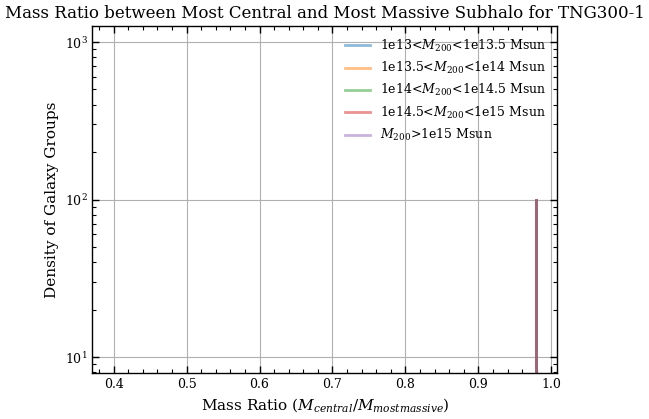

In [41]:
#plot the mass ratio distribution (most central / most massive) for these mass bins
prob_mass_ratio_plotter = AstroPlotter()
prob_mass_ratio_fig, prob_mass_ratio_ax = prob_mass_ratio_plotter.create_figure()
bins = np.linspace(0.4, 1, 30)
prob_mass_ratio_plotter.histogram(
    [gg.getMostCentralSubhalo().getStellarMass() / gg.getMostMassiveSubhalo().getStellarMass() for gg in filtered_13_13p5_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_mass_ratio_ax,
    xlabel='Mass Ratio between Most Central and Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'Mass Ratio between Most Central and Most Massive Subhalo for {sim}',
    label='1e13<$M_{{200}}$<1e13.5 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=None,
    percentage=True,
    grid=True,
)
prob_mass_ratio_plotter.histogram(
    [gg.getMostCentralSubhalo().getStellarMass() / gg.getMostMassiveSubhalo().getStellarMass() for gg in filtered_13p5_14_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_mass_ratio_ax,
    xlabel='Mass Ratio between Most Central and Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'Mass Ratio between Most Central and Most Massive Subhalo for {sim}',
    label='1e13.5<$M_{{200}}$<1e14 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=None,
    percentage=True,
    grid=True,
)
prob_mass_ratio_plotter.histogram(
    [gg.getMostCentralSubhalo().getStellarMass() / gg.getMostMassiveSubhalo().getStellarMass() for gg in filtered_14_14p5_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_mass_ratio_ax,
    xlabel='Mass Ratio between Most Central and Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'Mass Ratio between Most Central and Most Massive Subhalo for {sim}',
    label='1e14<$M_{{200}}$<1e14.5 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=None,
    percentage=True,
    grid=True,
)
prob_mass_ratio_plotter.histogram(
    [gg.getMostCentralSubhalo().getStellarMass() / gg.getMostMassiveSubhalo().getStellarMass() for gg in filtered_14p5_15_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_mass_ratio_ax,
    xlabel='Mass Ratio between Most Central and Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'Mass Ratio between Most Central and Most Massive Subhalo for {sim}',
    label='1e14.5<$M_{{200}}$<1e15 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=None,
    percentage=True,
    grid=True,
)
prob_mass_ratio_plotter.histogram(
    [gg.getMostCentralSubhalo().getStellarMass() / gg.getMostMassiveSubhalo().getStellarMass() for gg in filtered_gt15_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_mass_ratio_ax,
    xlabel='Mass Ratio ($M_{{central}} / M_{{most massive}}$)',
    ylabel='Density of Galaxy Groups',
    title=f'Mass Ratio between Most Central and Most Massive Subhalo for {sim}',
    label='$M_{{200}}$>1e15 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=scratchPlotDirc + f'/central_disparities/most_massive_vs_most_central_massRatio_{sim}_massBins.png',
    percentage=True,
    grid=True,
)

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/central_disparities/most_massive_r_ratio_r200_TNG300-1_massBins.png


(<Figure size 600x450 with 1 Axes>,
 <Axes: title={'center': 'r/r200 of Most Massive Subhalo for TNG300-1'}, xlabel='r/r200 of Most Massive Subhalo', ylabel='Density of Galaxy Groups'>)

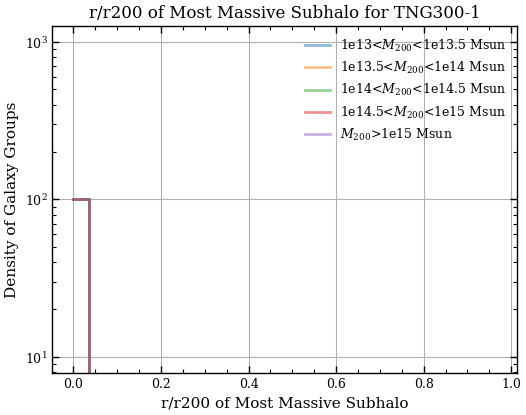

In [42]:
# plot the r/r200 of the most massive subhalo for these mass bins
prob_massive_r_ratio_plotter = AstroPlotter()
prob_massive_r_ratio_fig, prob_massive_r_ratio_ax = prob_massive_r_ratio_plotter.create_figure()
bins = np.linspace(0, 1, 30)
prob_massive_r_ratio_plotter.histogram(
    [np.linalg.norm(gg.getMostMassiveSubhalo().getPosition()) / gg.getRCrit200() for gg in filtered_13_13p5_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_massive_r_ratio_ax,
    xlabel='r/r200 of Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'r/r200 of Most Massive Subhalo for {sim}',
    label='1e13<$M_{{200}}$<1e13.5 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=None,
    percentage=True,
    grid=True,
)
prob_massive_r_ratio_plotter.histogram(
    [np.linalg.norm(gg.getMostMassiveSubhalo().getPosition()) / gg.getRCrit200() for gg in filtered_13p5_14_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_massive_r_ratio_ax,
    xlabel='r/r200 of Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'r/r200 of Most Massive Subhalo for {sim}',
    label='1e13.5<$M_{{200}}$<1e14 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=None,
    percentage=True,
    grid=True,
)
prob_massive_r_ratio_plotter.histogram(
    [np.linalg.norm(gg.getMostMassiveSubhalo().getPosition()) / gg.getRCrit200() for gg in filtered_14_14p5_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_massive_r_ratio_ax,
    xlabel='r/r200 of Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'r/r200 of Most Massive Subhalo for {sim}',
    label='1e14<$M_{{200}}$<1e14.5 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=None,
    percentage=True,
    grid=True,
)
prob_massive_r_ratio_plotter.histogram(
    [np.linalg.norm(gg.getMostMassiveSubhalo().getPosition()) / gg.getRCrit200() for gg in filtered_14p5_15_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_massive_r_ratio_ax,
    xlabel='r/r200 of Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'r/r200 of Most Massive Subhalo for {sim}',
    label='1e14.5<$M_{{200}}$<1e15 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=None,
    percentage=True,
    grid=True,
)
prob_massive_r_ratio_plotter.histogram(
    [np.linalg.norm(gg.getMostMassiveSubhalo().getPosition()) / gg.getRCrit200() for gg in filtered_gt15_list_of_galaxy_groups.getAllGalaxyGroups()],
    bins=bins,
    ax = prob_massive_r_ratio_ax,
    xlabel='r/r200 of Most Massive Subhalo',
    ylabel='Density of Galaxy Groups',
    title=f'r/r200 of Most Massive Subhalo for {sim}',
    label='$M_{{200}}$>1e15 Msun',
    ylog=True,
    legend=True,
    linealpha=0.5,
    output_filename=scratchPlotDirc + f'/central_disparities/most_massive_r_ratio_r200_{sim}_massBins.png',
    percentage=True,
    grid=True,
)

In [43]:
# plot the median number of subhalos within r200 for these mass bins
def plot_median_num_subhalos_by_mass_bins(listGG : list[tuple[ListGalaxyGroup, str]]):
    median_subhalo_plotter = AstroPlotter()
    median_subhalo_fig, median_subhalo_ax = median_subhalo_plotter.create_figure()
    bins = np.linspace(0, 500, 100)
    mass_bin_labels = []
    for i, (mass_filtered_list, mass_bin_label) in enumerate(listGG):
        median_num_subhalos = []
        for galaxy_group in mass_filtered_list.getAllGalaxyGroups():
            median_num = len(galaxy_group.getSatelliteSubhalos())
            median_num_subhalos.append(median_num)
        mass_bin_labels.append(mass_bin_label)
        print(f"Mass bin: {mass_bin_label}, median number of subhalos: {median_num}")
    
        median_subhalo_plotter.histogram(
            median_num_subhalos,
            bins=bins,
            ax= median_subhalo_ax,
            xlabel='Number of Satellite Subhalos within r200',
            ylabel='Density of Galaxy Groups',
            title=f'Number of Satellite Subhalos within r200 for {sim}',
            label=mass_bin_label,
            ylog=True,
            legend=True,
            linealpha=0.5,
            output_filename=None,
            percentage=True,
            grid=True,
        )
    median_subhalo_plotter.save_figure(
        fig=median_subhalo_fig,
        filename=scratchPlotDirc + f'/median_num_subhalos_by_mass_bins_{sim}.png'
    )

Mass bin: 1e13<$M_{{200}}$<1e13.5 Msun, median number of subhalos: 12
Mass bin: 1e13.5<$M_{{200}}$<1e14 Msun, median number of subhalos: 23
Mass bin: 1e14<$M_{{200}}$<1e14.5 Msun, median number of subhalos: 57
Mass bin: 1e14.5<$M_{{200}}$<1e15 Msun, median number of subhalos: 294
Mass bin: $M_{{200}}$>1e15 Msun, median number of subhalos: 420
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/median_num_subhalos_by_mass_bins_TNG300-1.png


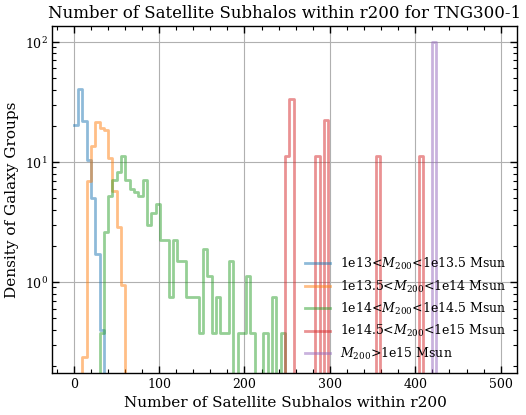

In [44]:
plot_median_num_subhalos_by_mass_bins([(filtered_13_13p5_list_of_galaxy_groups, '1e13<$M_{{200}}$<1e13.5 Msun'),
                                       (filtered_13p5_14_list_of_galaxy_groups, '1e13.5<$M_{{200}}$<1e14 Msun'),
                                       (filtered_14_14p5_list_of_galaxy_groups, '1e14<$M_{{200}}$<1e14.5 Msun'),
                                       (filtered_14p5_15_list_of_galaxy_groups, '1e14.5<$M_{{200}}$<1e15 Msun'),
                                       (filtered_gt15_list_of_galaxy_groups, '$M_{{200}}$>1e15 Msun')]) 

In [19]:
#plot the pairwise polar differences for these mass bins and split between central is most massive or not
def plot_pairwise_polar_by_mass_bins_and_centralMassive_status(listGG : list[tuple[ListGalaxyGroup, str]]): #mass_filtered_list : ListGalaxyGroup, mass_bin_label):
    prob_polar_mass_plotter = AstroPlotter()
    prob_polar_mass_fig, prob_polar_mass_ax = prob_polar_mass_plotter.create_figure(ncols=1, nrows=len(listGG), figsize=(8, 6*len(listGG)))

    colors = ['blue', 'orange', 'red', 'green', 'purple']                                                          
    for i, (mass_filtered_list, mass_bin_label) in enumerate(listGG):
        central_most_massive_list_of_galaxy_groups = mass_filtered_list.getFilterSubhalos(centralIsMostMassive=True)
        not_central_most_massive_list_of_galaxy_groups = mass_filtered_list.getFilterSubhalos(centralIsMostMassive=False)
        print(f"len GG: {len(central_most_massive_list_of_galaxy_groups.getAllGalaxyGroups()), len(not_central_most_massive_list_of_galaxy_groups.getAllGalaxyGroups())}")

        list_pairwise_polar_differences_centralMassive = central_most_massive_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=False)
        list_pairwise_polar_differences_notCentralMassive = not_central_most_massive_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=False)
        list_pairwise_polar_differences_total = mass_filtered_list.compute_probablity_distribution_of_polar_differences(parallelize=False)
        
        pairwise_polar_differences_centralMassive, polar_bin_centers_centralMassive, pairwise_polar_centralMassive_errorbars = ListGalaxyGroup.get_histogram_bins(list_pairwise_polar_differences_centralMassive, bins = np.arange(0, 185, 10), errorbarType='bootstrap')
        pairwise_polar_differences_notCentralMassive, polar_bin_centers_notCentralMassive, pairwise_polar_notCentralMassive_errorbars = ListGalaxyGroup.get_histogram_bins(list_pairwise_polar_differences_notCentralMassive, bins = np.arange(0, 185, 10), errorbarType='bootstrap')
        pairwise_polar_differences_total, polar_bin_centers_total, pairwise_polar_total_errorbars = ListGalaxyGroup.get_histogram_bins(list_pairwise_polar_differences_total, bins = np.arange(0, 185, 10), errorbarType='bootstrap')
    
        if len(listGG) > 1:
            print(f"choosing ax, {i}")
            axToPlot = prob_polar_mass_ax[i]
        else:
            axToPlot = prob_polar_mass_ax
        print(f"len: {len(polar_bin_centers_centralMassive), len(polar_bin_centers_notCentralMassive), len(polar_bin_centers_total)}")
        print(f"first 5 values centralMassive: {pairwise_polar_differences_centralMassive[:5]}, notCentralMassive: {pairwise_polar_differences_notCentralMassive[:5]}, total: {pairwise_polar_differences_total[:5]}")

        prob_polar_mass_plotter.scatter_plot(
            polar_bin_centers_centralMassive, 
            pairwise_polar_differences_centralMassive,
            # errorBars = pairwise_polar_centralMassive_errorbars,
            ax=axToPlot, # Use the same axis for overlay
            overlay_color=colors[0],
            # xlabel='Pairwise Polar Difference (degrees)',
            # ylabel='Probability Density',
            # title=f'Probability Pairwise Polar Difference Distribution for {sim} ({mass_bin_label})',
            # ylim = (0, 0.01),
            label="Central is Most Massive",
            # output_filename=None,  # Disable saving for combined plot
            # grid=True,
        )
        prob_polar_mass_plotter.scatter_plot(
            polar_bin_centers_notCentralMassive, 
            pairwise_polar_differences_notCentralMassive,
            # errorBars = pairwise_polar_notCentralMassive_errorbars,
            ax=axToPlot,  # Use the same axis for overlay
            overlay_color=colors[1], 
            # xlabel='Pairwise Polar Difference (degrees)',
            # ylabel='Probability Density',
            # title=f'Probability Pairwise Polar Difference Distribution for {sim} ({mass_bin_label})',
            # ylim = (0, 0.01),
            label="Central is NOT Most Massive",
            # include_legend=True,
            # output_filename=None,
            # grid=True,
        )
        prob_polar_mass_plotter.scatter_plot(
            polar_bin_centers_total, 
            pairwise_polar_differences_total,
            # errorBars = pairwise_polar_total_errorbars,
            ax=axToPlot,  # Use the same axis for overlay
            overlay_color=colors[2],
            xlabel='Pairwise Polar Difference (degrees)',
            ylabel='Probability Density',
            title=f'Probability Pairwise Polar Difference Distribution for {sim} ({mass_bin_label})',
            # ylim = (0, 0.01),
            s=10,
            
            label="All Galaxy Groups",
            include_legend=True,
            # output_filename=scratchPlotDirc + f'/pairwise_polar_difference_total_{mass_bin_label.replace("<","lt").replace(">","gt")}_{sim}.png',
            grid=True,
        )

        
    return prob_polar_mass_plotter, prob_polar_mass_fig, prob_polar_mass_ax

total to process: 3032
total to process: 3032alaxy Group ID 3032 / 3032
len GG: (3032, 0)ing Galaxy Group ID 3032 / 3032
Total Galaxy Groups to process: 3032 with pairs : 228318
Processing Subhalo 12/12 in Galaxy Group ID 999 with total pairs 6615Total Galaxy Groups to process: 0 with pairs : 0
Total Galaxy Groups to process: 3032 with pairs : 228318
Bootstrapping... Current std of bootstrap means: nan, Original mean: 0.0056

/home/poulin.al/.conda/envs/myenv/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


choosing ax, 0
len: (18, 18, 18)
first 5 values centralMassive: [0.00678285 0.00634416 0.00594791 0.00577659 0.00554828], notCentralMassive: [nan nan nan nan nan], total: [0.00678285 0.00634416 0.00594791 0.00577659 0.00554828]
total to process: 420
total to process: 420Galaxy Group ID 420 / 420
len GG: (420, 0)sing Galaxy Group ID 420 / 420
Total Galaxy Groups to process: 420 with pairs : 253173
Processing Subhalo 23/23 in Galaxy Group ID 946 with total pairs 2535Total Galaxy Groups to process: 0 with pairs : 0
Total Galaxy Groups to process: 420 with pairs : 253173
Bootstrapping... Current std of bootstrap means: nan, Original mean: 0.0056choosing ax, 1
len: (18, 18, 18)
first 5 values centralMassive: [0.00634162 0.00612875 0.00592731 0.00575805 0.00559881], notCentralMassive: [nan nan nan nan nan], total: [0.00634162 0.00612875 0.00592731 0.00575805 0.00559881]
total to process: 268
total to process: 268Galaxy Group ID 268 / 268
len GG: (268, 0)sing Galaxy Group ID 268 / 268
Total G

(<myproject.utilities.plottingTools.AstroPlotter at 0x1503fe1107d0>,
 <Figure size 800x3000 with 5 Axes>,
 array([<Axes: title={'center': 'Probability Pairwise Polar Difference Distribution for TNG300-1 (1e13<$M_{{200}}$<1e13.5 Msun)'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>,
        <Axes: title={'center': 'Probability Pairwise Polar Difference Distribution for TNG300-1 (1e13.5<$M_{{200}}$<1e14 Msun)'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>,
        <Axes: title={'center': 'Probability Pairwise Polar Difference Distribution for TNG300-1 (1e14<$M_{{200}}$<1e14.5 Msun)'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>,
        <Axes: title={'center': 'Probability Pairwise Polar Difference Distribution for TNG300-1 (1e14.5<$M_{{200}}$<1e15 Msun)'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>,
        <Axes: title={'center': 'Probability Pairwise Polar Di

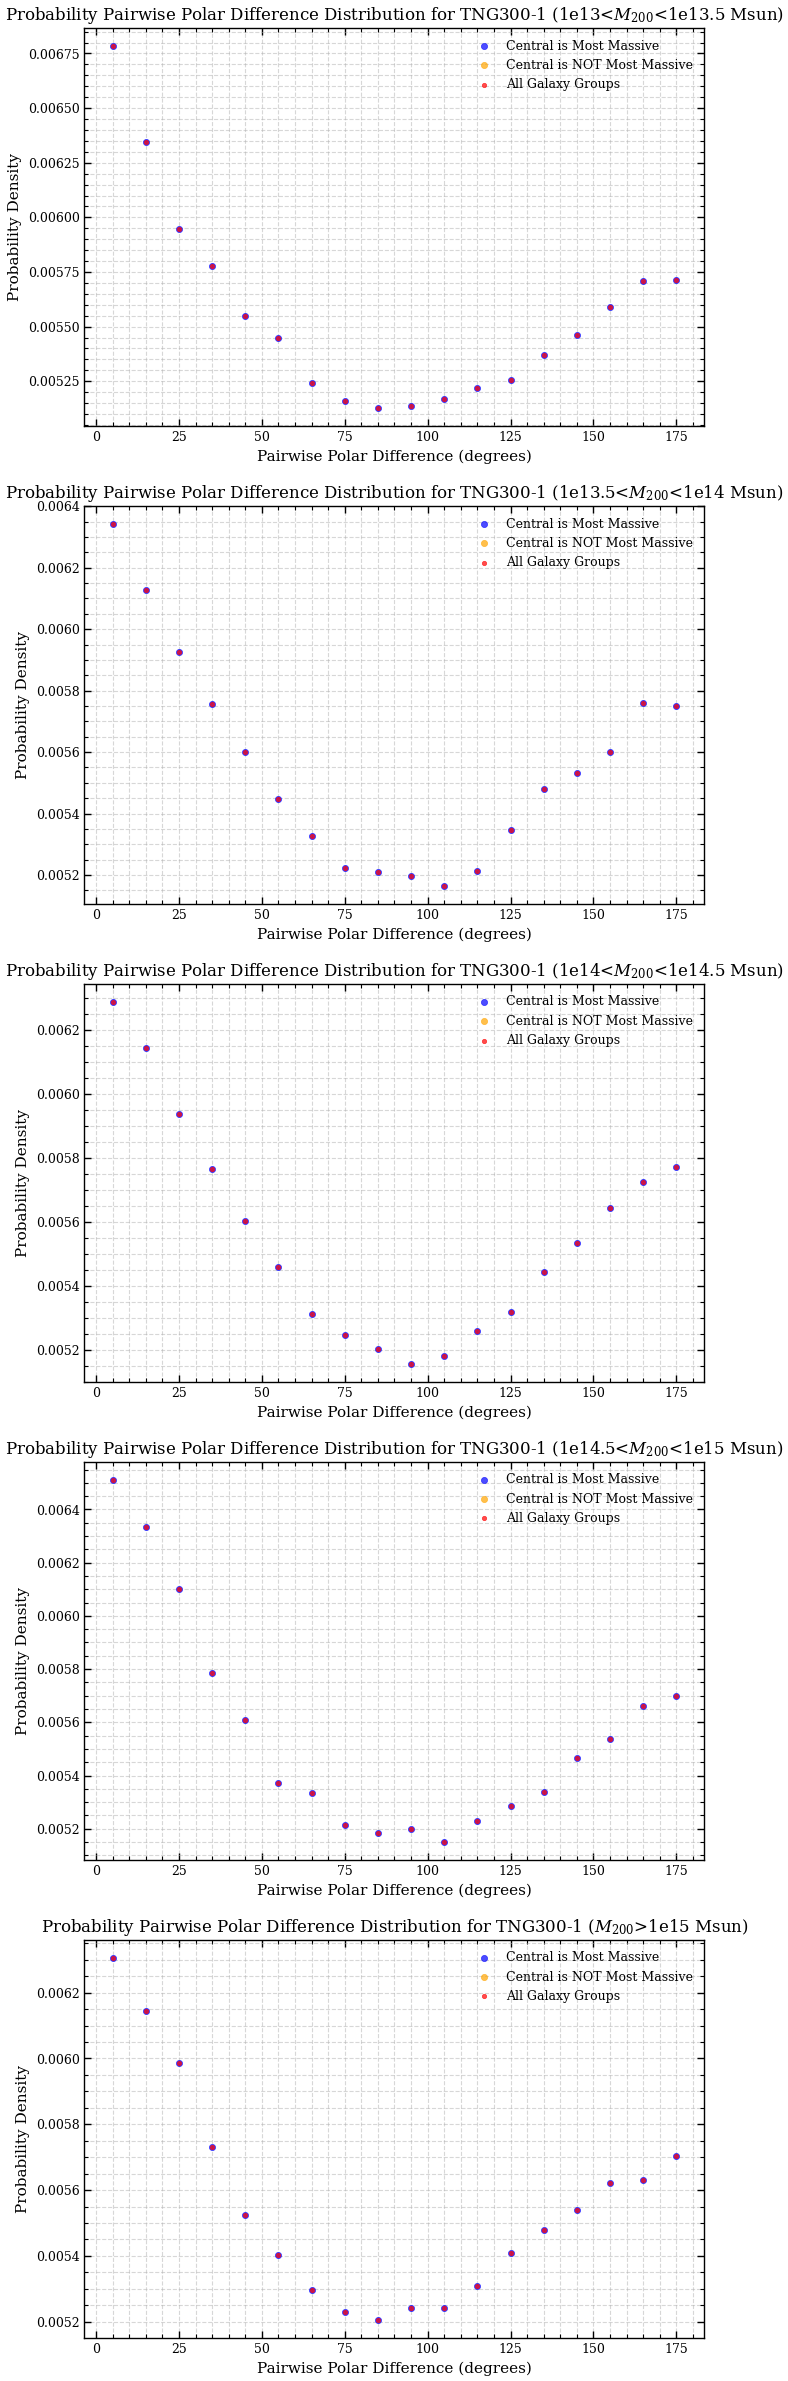

In [20]:
# run for each mass bin
plot_pairwise_polar_by_mass_bins_and_centralMassive_status([(filtered_13_13p5_list_of_galaxy_groups, '1e13<$M_{{200}}$<1e13.5 Msun'),
                                                            (filtered_13p5_14_list_of_galaxy_groups, '1e13.5<$M_{{200}}$<1e14 Msun'),
                                                            (filtered_14_14p5_list_of_galaxy_groups, '1e14<$M_{{200}}$<1e14.5 Msun'),
                                                            (filtered_14p5_15_list_of_galaxy_groups, '1e14.5<$M_{{200}}$<1e15 Msun'),
                                                            (filtered_gt15_list_of_galaxy_groups, '$M_{{200}}$>1e15 Msun')])
# plot_pairwise_polar_by_mass_bins_and_centralMassive_status([
#                                                             (filtered_gt15_list_of_galaxy_groups, '$M_{{200}}$>1e15 Msun')])

total to process: 3732
total to process: 3732alaxy Group ID 3732 / 3732
len GG: (3732, 0)ing Galaxy Group ID 3732 / 3732
Total Galaxy Groups to process: 3732 with pairs : 2549893
Processing Subhalo 12/12 in Galaxy Group ID 999 with total pairs 661210Total Galaxy Groups to process: 0 with pairs : 0
Total Galaxy Groups to process: 3732 with pairs : 2549893
Bootstrapping... Current std of bootstrap means: nan, Original mean: 0.0056len: (18, 18, 18)
first 5 values centralMassive: [0.00637127 0.0061891  0.005973   0.00576268 0.0055851 ], notCentralMassive: [nan nan nan nan nan], total: [0.00637127 0.0061891  0.005973   0.00576268 0.0055851 ]


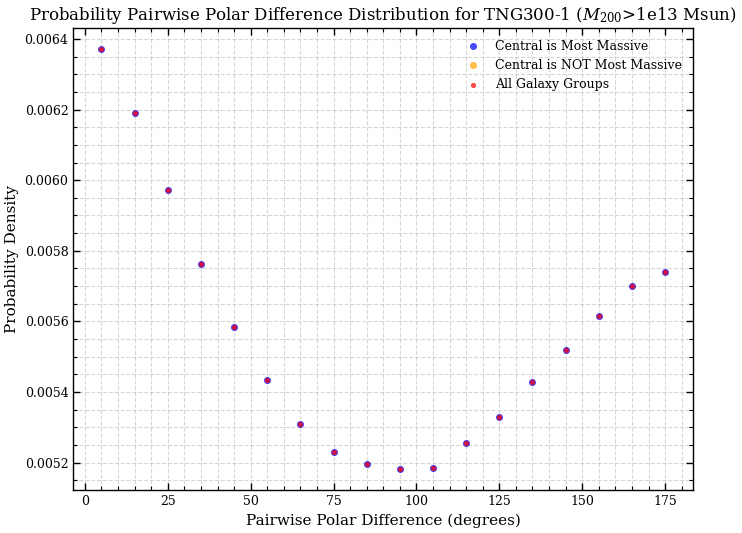

In [21]:
#plot for all galaxy groups with central most massive vs not central most massive without splitting into mass bins
prob_polar_mass_plotter, prob_polar_mass_fig, prob_polar_mass_ax = plot_pairwise_polar_by_mass_bins_and_centralMassive_status([(list_of_galaxy_groups, '$M_{{200}}$>1e13 Msun')])

In [22]:
#replot this with different ylims
prob_polar_mass_ax.set_ylim(0.0050, 0.0065)
prob_polar_mass_plotter.save_figure(prob_polar_mass_fig, scratchPlotDirc + f'/pairwise_polar_difference_allMasses_{sim}_differentYlim.png')

#overlay
# polar_bin_centers, pairwise_polar_differences, pairwise_polar_errorbars
prob_polar_mass_ax.errorbar(polar_bin_centers, pairwise_polar_differences_binned, yerr=pairwise_polar_errorbars, fmt='o', label='All Galaxy Groups', color='black', markersize=3, alpha=0.5)
prob_polar_mass_ax.legend()
prob_polar_mass_plotter.save_figure(prob_polar_mass_fig, scratchPlotDirc + f'/pairwise_polar_difference_allMasses_{sim}_overlay.png')

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/pairwise_polar_difference_allMasses_TNG300-1_differentYlim.png
Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/pairwise_polar_difference_allMasses_TNG300-1_overlay.png


## create MRL random distribution curves

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:232: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,
/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:243: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/MRL_distribution_curves_TNG300-1.png
(np.float64(-1.6033611867910917), np.float64(12.815398151751962))
(np.float64(-1.6033611867910917), np.float64(12.815398151751962))


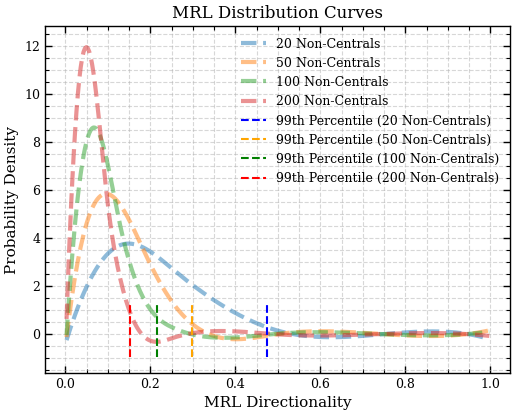

In [24]:
MRL_20_values = ListGalaxyGroup.compute_an_MRL_distribution_curves(parallelize=False, num_samples=10000, num_non_centrals=20)
MRL_20, MRL_20_bin_edges, MRL_20_errorbars = ListGalaxyGroup.get_histogram_bins(MRL_20_values, binsize=0.005, binLow=0, binHigh=1, errorbarType='poisson')

MRL_50_values = ListGalaxyGroup.compute_an_MRL_distribution_curves(parallelize=False, num_samples=10000, num_non_centrals=50)
MRL_50, MRL_50_bin_edges, MRL_50_errorbars = ListGalaxyGroup.get_histogram_bins(MRL_50_values, binsize=0.005, binLow=0, binHigh=1, errorbarType='poisson')

MRL_100_values = ListGalaxyGroup.compute_an_MRL_distribution_curves(parallelize=False, num_samples=10000, num_non_centrals=100)
MRL_100, MRL_100_bin_edges, MRL_100_errorbars = ListGalaxyGroup.get_histogram_bins(MRL_100_values, binsize=0.005, binLow=0, binHigh=1, errorbarType='poisson')

MRL_200_values = ListGalaxyGroup.compute_an_MRL_distribution_curves(parallelize=False, num_samples=10000, num_non_centrals=200)
MRL_200, MRL_200_bin_edges, MRL_200_errorbars = ListGalaxyGroup.get_histogram_bins(MRL_200_values, binsize=0.005, binLow=0, binHigh=1, errorbarType='poisson')

# print(len(MRL_20), len(MRL_20_bin_edges))
# print(MRL_20[MRL_20 > 0])
#plot with spline curve
MRL_plotter = AstroPlotter()
MRL_fig, MRL_ax = MRL_plotter.create_figure()
MRL_plotter.scatter_plot(
    MRL_20_bin_edges, 
    MRL_20,
    # errorBars = MRL_20_errorbars,
    ax=MRL_ax, # Use the same axis for overlay
    # ylim = (0, 0.01),
    label="20 Non-Centrals",
    alpha=0,
    s=50,
    output_filename=None,  # Disable saving for combined plot
    grid=True,
    spline_curvature=True,
)
#plot a small verticle line at 99th percentile of MRL_20_values
percentile_99_MRL_20 = np.percentile(MRL_20_values, 99)
# MRL_ax.axvline(percentile_99_MRL_20, color='blue', linestyle='--', label='99th Percentile (20 Non-Centrals)')

MRL_plotter.scatter_plot(
    MRL_50_bin_edges, 
    MRL_50,
    # errorBars = MRL_50_errorbars,
    ax=MRL_ax,  # Use the same axis for overlay
    # ylim = (0, 0.01),
    label="50 Non-Centrals",
    alpha=0,
    output_filename=None,
    grid=True,
    spline_curvature=True,
)
#plot a small verticle line at 99th percentile of MRL_50_values
percentile_99_MRL_50 = np.percentile(MRL_50_values, 99)
# MRL_ax.axvline(percentile_99_MRL_50, color='orange', linestyle='--', label='99th Percentile (50 Non-Centrals)')


MRL_plotter.scatter_plot(
    MRL_100_bin_edges, 
    MRL_100,
    # errorBars = MRL_100_errorbars,
    ax=MRL_ax,  # Use the same axis for overlay
    # ylim = (0, 0.01),
    label="100 Non-Centrals",
    alpha=0,
    output_filename=None,
    grid=True,
    spline_curvature=True,
)
#plot a small verticle line at 99th percentile of MRL_100_values
percentile_99_MRL_100 = np.percentile(MRL_100_values, 99)
# MRL_ax.axvline(percentile_99_MRL_100, color='red', linestyle='--', label='99th Percentile (100 Non-Centrals)')


MRL_plotter.scatter_plot(
    MRL_200_bin_edges, 
    MRL_200,
    # errorBars = MRL_500_errorbars,
    ax=MRL_ax,  # Use the same axis for overlay
    xlabel='MRL Directionality',
    ylabel='Probability Density',
    title=f'MRL Distribution Curves',
    # ylim = (0, 0.01),
    label="200 Non-Centrals",
    alpha=0,
    output_filename=scratchPlotDirc + f'/MRL_distribution_curves_{sim}.png',
    include_legend=True,
    grid=True,
    spline_curvature=True,
)
#plot a small verticle line at 99th percentile of MRL_200_values
percentile_99_MRL_200 = np.percentile(MRL_200_values, 99)
# MRL_ax.axvline(percentile_99_MRL_200, color='green', linestyle='--', label='99th Percentile (200 Non-Centrals)')

ymin, ymax = MRL_ax.get_ylim()
MRL_ax.plot([percentile_99_MRL_20, percentile_99_MRL_20], [ymin, ymax*0.1], color='blue', linestyle='--', label='99th Percentile (20 Non-Centrals)')
print(MRL_ax.get_ylim())
MRL_ax.plot([percentile_99_MRL_50, percentile_99_MRL_50], [ymin, ymax*0.1], color='orange', linestyle='--', label='99th Percentile (50 Non-Centrals)')
print(MRL_ax.get_ylim())
MRL_ax.plot([percentile_99_MRL_100, percentile_99_MRL_100], [ymin, ymax*0.1], color='green', linestyle='--', label='99th Percentile (100 Non-Centrals)')
MRL_ax.plot([percentile_99_MRL_200, percentile_99_MRL_200], [ymin, ymax*0.1], color='red', linestyle='--', label='99th Percentile (200 Non-Centrals)')
MRL_ax.legend()

In [19]:
list_of_galaxy_groups_gt13 = list_of_galaxy_groups.getFilterSubhalos(minGGMass=1e13)


total to process: 3732


In [20]:
MRL_gt14_values = filtered_list_of_galaxy_groups.compute_probablity_distribution_of_MRL_directionality(parallelize=False)
random_MRL_values_gt14 = filtered_list_of_galaxy_groups.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=10000)


final: [np.float64(0.07055262092751405), np.float64(0.06882863379814345), np.float64(0.0791280534930706)]


In [62]:
print(type(random_MRL_values_gt14), type(random_MRL_values_gt14[0]))

<class 'list'> <class 'list'>


Bootstrapping... Current std of bootstrap means: nan, Original mean: 1.0000Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/MRL_gt13_with_random_TNG300-1.png


(<Figure size 600x450 with 1 Axes>,
 <Axes: title={'center': 'MRL Directionality for Galaxy Groups with $M_{200}$>1e13 Msun in TNG300-1'}, xlabel='MRL Directionality', ylabel='Probability Density'>)

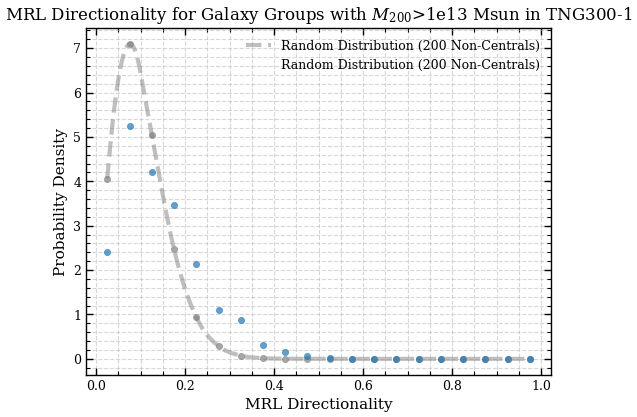

In [ ]:
#plot the MRL values for all galaxy groups and highlight those above the 99th percentile for the 200 non-centrals case
# list_of_galaxy_groups_gt13 = list_of_galaxy_groups.getFilterSubhalos(minGGMass=1e13)
# MRL_values = filtered_list_of_galaxy_groups.compute_probablity_distribution_of_MRL_directionality(parallelize=False, tempSaveDir=f'{scratchDataDirc}/MRL_directionality', rewrite=True)#rewrite=generalRewrite)
# MRL_directionality, MRL_bin_centers, MRL_errorbars = filtered_list_of_galaxy_groups.get_histogram_bins(MRL_values, binsize=0.05, binLow=0, binHigh=1, errorbarType='poisson')
MRL_gt14_bins, MRL_gt14_bin_centers, MRL_gt14_errorbars = ListGalaxyGroup.get_histogram_bins(MRL_gt14_values, binsize=0.05, binLow=0, binHigh=1, errorbarType='bootstrap')
random_MRL_gt14_bins, random_MRL_gt14_bin_centers, random_MRL_gt14_errorbars = ListGalaxyGroup.get_histogram_bins(np.concatenate(random_MRL_values_gt14), binsize=0.05, binLow=0, binHigh=1, errorbarType='bootstrap')

MRL_gt14_plotter = AstroPlotter()
MRL_gt14_fig, MRL_gt14_ax = MRL_gt14_plotter.create_figure()
#plot the random MRL distribution on the same plot
MRL_gt14_plotter.scatter_plot(
    random_MRL_gt14_bin_centers, 
    random_MRL_gt14_bins,
    # errorBars = random_MRL_gt13_errorbars,
    ax=MRL_gt14_ax,  # Use the same axis for overlay
    # ylim = (0, 0.01),
    label="Random Distribution (200 Non-Centrals)",
    overlay_color='gray',
    # alpha=0,
    output_filename=None,
    include_legend=True,
    grid=True,
    spline_curvature=True,
    spline_smoothing=0,
)
MRL_gt14_plotter.scatter_plot(
    random_MRL_gt14_bin_centers, 
    random_MRL_gt14_bins,
    # errorBars = random_MRL_gt13_errorbars,
    ax=MRL_gt14_ax,  # Use the same axis for overlay
    # ylim = (0, 0.01),
    label="Random Distribution (200 Non-Centrals)",
    overlay_color='gray',
    alpha=0,
    output_filename=None,
    include_legend=True,
    grid=True,
)
MRL_gt14_plotter.scatter_plot(
    MRL_gt14_bin_centers, 
    MRL_gt14_bins,
    # errorBars = MRL_gt13_errorbars,
    ax=MRL_gt14_ax, # Use the same axis for overlay
    xlabel='MRL Directionality',
    ylabel='Probability Density',
    title=f'MRL Directionality for Galaxy Groups with $M_{{200}}$>1e14 Msun in {sim}',
    # ylim = (0, 0.01),
    label="Galaxy Groups",
    output_filename=scratchPlotDirc + f'/MRL_gt14_with_random_{sim}.png',
    grid=True,
)

In [69]:
#overlay Prof TGB data to see if it matches well
#her file is in format: MRL_value, Probability_density_MRL_value, errorbar_MRL_value (already binned and processed)
profTGB_data = np.loadtxt(f'{scratchDataDirc}/TGB_data/mrl_prob_tng.txt')
profTGB_random_MRL_values = np.loadtxt(f'{scratchDataDirc}/TGB_data/mrl_prob_RANDOM.txt')
profTGB_MRL_values = profTGB_data[:, 0]
profTGB_MRL_prob = profTGB_data[:, 1]
profTGB_MRL_errorbars = profTGB_data[:, 2]

MRL_gt14_plotter.scatter_plot(
    profTGB_MRL_values, 
    profTGB_MRL_prob,
    errorBars = profTGB_MRL_errorbars,
    ax=MRL_gt14_ax, # Use the same axis for overlay
    overlay_color='red',
    label="Prof TGB TNG Data",
    include_legend=True,
    output_filename=None,
    grid=True,
)
MRL_gt14_plotter.scatter_plot(
    profTGB_random_MRL_values[:, 0], 
    profTGB_random_MRL_values[:, 1],
    errorBars = profTGB_random_MRL_values[:, 2],
    ax=MRL_gt14_ax, # Use the same axis for overlay
    overlay_color='brown',
    # label="Prof TGB TNG Random Distribution",
    # include_legend=True,
    output_filename=None,
    grid=True,
    alpha=0,
    spline_curvature=True,
    spline_smoothing=0,
)
MRL_gt14_plotter.scatter_plot(
    profTGB_random_MRL_values[:, 0], 
    profTGB_random_MRL_values[:, 1],
    errorBars = profTGB_random_MRL_values[:, 2],
    ax=MRL_gt14_ax, # Use the same axis for overlay
    overlay_color='brown',
    label="Prof TGB TNG Random Distribution",
    include_legend=True,
    output_filename=None,
    grid=True,
)

MRL_gt14_ax.legend()
MRL_gt14_plotter.save_figure(MRL_gt14_fig, scratchPlotDirc + f'/MRL_gt13_with_random_and_TGB_{sim}.png')

Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/MRL_gt13_with_random_and_TGB_TNG300-1.png


In [21]:
MRL_gt13_values = list_of_galaxy_groups_gt13.compute_probablity_distribution_of_MRL_directionality(parallelize=False)
random_MRL_values_gt13 = list_of_galaxy_groups_gt13.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=1000)


final: [np.float64(0.07055262092751405), np.float64(0.06882863379814345), np.float64(0.0791280534930706)]


final: [np.float64(0.07055262092751405), np.float64(0.06882863379814345), np.float64(0.0791280534930706)]


<string>:55: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
<string>:62: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/MRL_gt13_with_random_TNG300-1.png


(<Figure size 600x450 with 1 Axes>,
 <Axes: title={'center': 'MRL Directionality for Galaxy Groups with $M_{200}$>1e13 Msun in TNG300-1'}, xlabel='MRL Directionality', ylabel='Probability Density'>)

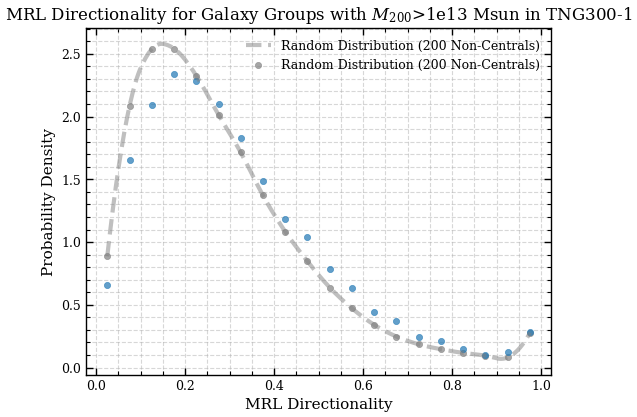

In [46]:
#plot the MRL values for all galaxy groups and highlight those above the 99th percentile for the 200 non-centrals case
# list_of_galaxy_groups_gt13 = list_of_galaxy_groups.getFilterSubhalos(minGGMass=1e13)
# MRL_gt13_values = list_of_galaxy_groups_gt13.compute_probablity_distribution_of_MRL_directionality(parallelize=False)
MRL_gt13_bins, MRL_gt13_bin_centers, MRL_gt13_errorbars = ListGalaxyGroup.get_histogram_bins(MRL_gt13_values, binsize=0.05, binLow=0, binHigh=1, errorbarType='poisson')

# random_MRL_values_gt13 = list_of_galaxy_groups_gt13.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=1000)
random_MRL_gt13_bins, random_MRL_gt13_bin_centers, random_MRL_gt13_errorbars = ListGalaxyGroup.get_histogram_bins(random_MRL_values_gt13, binsize=0.05, binLow=0, binHigh=1, errorbarType='poisson')

MRL_gt13_plotter = AstroPlotter()
MRL_gt13_fig, MRL_gt13_ax = MRL_gt13_plotter.create_figure()
#plot the random MRL distribution on the same plot
MRL_gt13_plotter.scatter_plot(
    random_MRL_gt13_bin_centers, 
    random_MRL_gt13_bins,
    # errorBars = random_MRL_gt13_errorbars,
    ax=MRL_gt13_ax,  # Use the same axis for overlay
    # ylim = (0, 0.01),
    label="Random Distribution (200 Non-Centrals)",
    overlay_color='gray',
    alpha=0,
    output_filename=None,
    include_legend=True,
    grid=True,
    spline_curvature=True,
    spline_smoothing=0,
)
MRL_gt13_plotter.scatter_plot(
    random_MRL_gt13_bin_centers, 
    random_MRL_gt13_bins,
    # errorBars = random_MRL_gt13_errorbars,
    ax=MRL_gt13_ax,  # Use the same axis for overlay
    # ylim = (0, 0.01),
    label="Random Distribution (200 Non-Centrals)",
    overlay_color='gray',
    # alpha=0,
    output_filename=None,
    include_legend=True,
    grid=True,
)
MRL_gt13_plotter.scatter_plot(
    MRL_gt13_bin_centers, 
    MRL_gt13_bins,
    # errorBars = MRL_gt13_errorbars,
    ax=MRL_gt13_ax, # Use the same axis for overlay
    xlabel='MRL Directionality',
    ylabel='Probability Density',
    title=f'MRL Directionality for Galaxy Groups with $M_{{200}}$>1e13 Msun in {sim}',
    # ylim = (0, 0.01),
    label="Galaxy Groups",
    output_filename=scratchPlotDirc + f'/MRL_gt13_with_random_{sim}.png',
    grid=True,
)

In [29]:
def overlayMRLAndMRLRandom(listGG : list[tuple[ListGalaxyGroup, str]]):
    overlayMRLPlotter = AstroPlotter()
    overlayMRLFig, overlayMRLAx = overlayMRLPlotter.create_figure(ncols=1, nrows = len(listGG), figsize=(8, 6*len(listGG)))
    
    numsamples=1000

    for i, (listGalaxyGroup, label) in enumerate(listGG):
        MRL_values = listGalaxyGroup.compute_probablity_distribution_of_MRL_directionality(parallelize=False)
        MRL_binned, MRL_bin_centers, MRL_errorbars = ListGalaxyGroup.get_histogram_bins(MRL_values, binsize=0.05, binLow=0, binHigh=1, errorbarType='poisson')
        
        random_MRL_values = listGalaxyGroup.compute_MRL_random_distribution_curves_for_LGG(parallelize=False, num_samples=numsamples)
        random_MRL_bins, random_MRL_bin_centers, random_MRL_errorbars = ListGalaxyGroup.get_histogram_bins(random_MRL_values, binsize=0.05, binLow=0, binHigh=1, errorbarType='poisson')
        
        if len(listGG) > 1:
            print(f"choosing ax, {i}")
            overlayAxToPlot = overlayMRLAx[i]
        else:
            overlayAxToPlot = overlayMRLAx

        overlayMRLPlotter.scatter_plot(
            MRL_bin_centers, 
            MRL_binned,
            # errorBars = MRL_errorbars,
            ax=overlayAxToPlot, # Use the same axis for overlay
            # ylim = (0, 0.01),
            label=f"MRL Directionality ({listGalaxyGroup.getNumGalaxyGroups()} Galaxy Groups in {label})",
            output_filename=None,  # Disable saving for combined plot
            grid=True
        )
        #plot a small verticle line at 99th percentile of radnom MRL_values
        percentile_99_MRL = np.percentile(random_MRL_values, 99)
        # overlayMRLAx.axvline(percentile_99_MRL, linestyle='--', label=f'99th Percentile')
        
        overlayMRLPlotter.scatter_plot(
            random_MRL_bin_centers, 
            random_MRL_bins,
            # errorBars = random_MRL_errorbars,
            ax=overlayAxToPlot,  # Use the same axis for overlay
            # ylim = (0, 0.01),
            label=f"Random MRL Directionality ({len(random_MRL_values)} Samples)",
            include_legend=True,
            overlay_color='gray',
            # output_filename=scratchPlotDirc + f'/MRL_distribution_curves_overlay_{sim}.png',
            output_filename=None,
            grid=True,
        )

        overlayMRLPlotter.scatter_plot(
            random_MRL_bin_centers, 
            random_MRL_bins,
            # errorBars = random_MRL_errorbars,
            ax=overlayAxToPlot,  # Use the same axis for overlay
            xlabel='MRL Directionality',
            ylabel='Probability Density',
            title=f'MRL Distribution Curves vs Random for {sim}, {label}',
            # ylim = (0, 0.01),
            label=f"Random MRL Directionality ({len(random_MRL_values)} Samples)",
            include_legend=True,
            overlay_color='gray',
            alpha=0,
            # output_filename=scratchPlotDirc + f'/MRL_distribution_curves_overlay_{sim}.png',
            output_filename=None,
            grid=True,
            spline_curvature=True,
            spline_smoothing=0,
        )
        print(f"99th percentile MRL: {percentile_99_MRL}")
        print(f"Overall number of MRL values above 99th percentile: {np.sum(np.array(MRL_values) > percentile_99_MRL)} out of {len(MRL_values)}")
        
        print(f"len listGG: {len(listGG)}, len MRL_values: {len(MRL_values)}, len random_MRL_values: {len(random_MRL_values)}")
        
        # save into .txt file:
        # In table: galaxy id, num of members, mass of cluster, MRL value of that projection, fraction less than the MRL I measured
        with open(scratchPlotDirc + f'/MRL_values_and_random_comparison_{label}.txt', 'w') as f:
            f.write("GalaxyGroupID\tNumMembers\tClusterMass\tMRLValue\tFractionLessThanMRL\n")
            for j, gg in enumerate(listGalaxyGroup.getAllGalaxyGroups()):
                print(f"processing galaxy group {j+1}/{len(listGalaxyGroup.getAllGalaxyGroups())} for fraction", end='\r', flush=True)
                gg_id = gg.getGroupID()
                num_members = gg.getNumSubhalos()
                cluster_mass = gg.getMCrit200()
                MRL_value = [MRL_values[j * 3], MRL_values[j * 3 + 1], MRL_values[j * 3 + 2]] if j * 3 + 2 < len(MRL_values) else [0, 0, 0]
                fraction_less_than_MRL =[np.sum(random_MRL_values[j] < MRL_values[j * 3]) / numsamples, np.sum(random_MRL_values[j] < MRL_values[j * 3 + 1]) / numsamples, np.sum(random_MRL_values[j] < MRL_values[j * 3 + 2]) / numsamples] if j * 3 + 2 < len(MRL_values) else [0, 0, 0]
                f.write(f"{gg_id}\t{num_members}\t{cluster_mass}\t{MRL_value}\t{fraction_less_than_MRL}\n")
                
        #save into .txt file, all the galaxy groups who's MRL_value is greater than 0.8
        with open(scratchPlotDirc + f'/high_MRL_galaxy_groups_{label}.txt', 'w') as f:
            f.write("GalaxyGroupID\tNumMembers\tClusterMass\tMRLValue\n")
            for k, gg in enumerate(listGalaxyGroup.getAllGalaxyGroups()):
                print(f"processing galaxy group {i+1}/{len(listGalaxyGroup.getAllGalaxyGroups())} for high MRL", end='\r', flush=True)
                gg_id = gg.getGroupID()
                num_members = gg.getNumSubhalos()
                cluster_mass = gg.getMCrit200()
                MRL_value = [MRL_values[k * 3], MRL_values[k * 3 + 1], MRL_values[k * 3 + 2]] if k * 3 + 2 < len(MRL_values) else [0, 0, 0]
                if np.any(np.array(MRL_value) > 0.8):
                    f.write(f"{gg_id}\t{num_members}\t{cluster_mass}\t{MRL_value}\n")
    # overlayAxToPlot.legend()
    overlayMRLPlotter.save_figure(overlayMRLFig, scratchPlotDirc + f'/MRL_distribution_curves_overlay_{sim}.png')
    
    #append into overall .txt file:
    with open(scratchPlotDirc + f'/MRL_values_and_random_comparison_overall.txt', 'a') as f:
        f.write(f"Simulation: {sim}\n")
        f.write("GalaxyGroupID\tNumMembers\tClusterMass\tMRLValue\tFractionLessThanMRL\n")
        for l, (listGalaxyGroup, label) in enumerate(listGG):
            with open(scratchPlotDirc + f'/MRL_values_and_random_comparison_{label}.txt', 'r') as g:
                lines = g.readlines()
                for line in lines[1:]:  # Skip header line
                    f.write(line)

In [27]:
#alternatively
overlayMRLAndMRLRandom([(list_of_galaxy_groups_gt13, '$M_{200}$>1e13 Msun')])

final: [np.float64(0.07055262092751405), np.float64(0.06882863379814345), np.float64(0.0791280534930706)]
99th percentile MRL: 0.9921834902584266ution for Galaxy Group 3732 / 3732 with 13 satellitess
Overall number of MRL values above 99th percentile: 117 out of 11196
len listGG: 1, len MRL_values: 11196, len random_MRL_values: 3732


final: [np.float64(0.07055262092751405), np.float64(0.06882863379814345), np.float64(0.0791280534930706)]
99th percentile MRL: 0.27306366429887113tion for Galaxy Group 280 / 280 with 58 satellitess
Overall number of MRL values above 99th percentile: 84 out of 840
len listGG: 1, len MRL_values: 840, len random_MRL_values: 280


<string>:55: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
<string>:62: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.


Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/plots/MRL_distribution_curves_overlay_TNG300-1.png


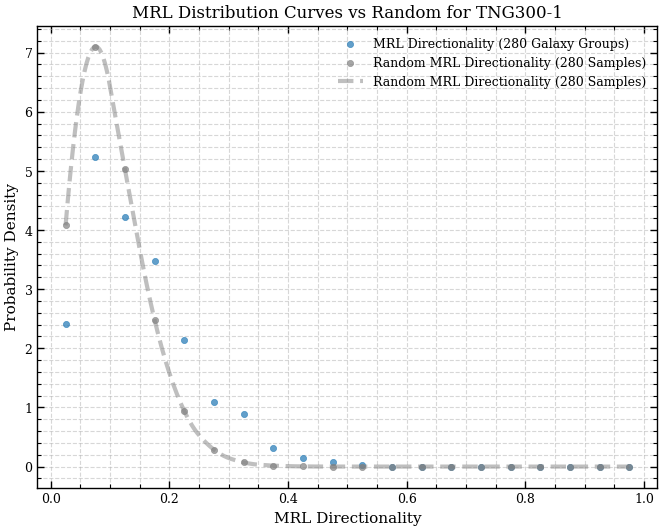

In [48]:
overlayMRLAndMRLRandom([(filtered_list_of_galaxy_groups, '$M_{200}$>1e14 Msun')])

In [28]:
print(filtered_13_13p5_list_of_galaxy_groups.compute_probablity_distribution_of_MRL_directionality(parallelize=False)[0])

0.0975578998699707ng Galaxy Group 3032 / 3032 with 13 satellites


choosing ax, 0essing random MRL distribution for Galaxy Group 3032 / 3032 with 13 satellites


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:232: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


99th percentile MRL: 0.9999999999999999
Overall number of MRL values above 99th percentile: 74 out of 9096
len listGG: 5, len MRL_values: 9096, len random_MRL_values: 3032


/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:243: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_smooth, spline(x_smooth),'k--', alpha=0.5, linewidth=3, c=scatter_color, label=label)


choosing ax, 1essing random MRL distribution for Galaxy Group 420 / 420 with 24 satellites
99th percentile MRL: 0.4016579833019997
Overall number of MRL values above 99th percentile: 64 out of 1260
len listGG: 5, len MRL_values: 1260, len random_MRL_values: 420
choosing ax, 2essing random MRL distribution for Galaxy Group 268 / 268 with 58 satellitess
99th percentile MRL: 0.27460444130173783
Overall number of MRL values above 99th percentile: 78 out of 804
len listGG: 5, len MRL_values: 804, len random_MRL_values: 268
choosing ax, 3essing random MRL distribution for Galaxy Group 9 / 9 with 295 satellites
99th percentile MRL: 0.12929163655611736
Overall number of MRL values above 99th percentile: 13 out of 27
len listGG: 5, len MRL_values: 27, len random_MRL_values: 9
final: [np.float64(0.07055262092751405), np.float64(0.06882863379814345), np.float64(0.0791280534930706)]
choosing ax, 4essing random MRL distribution for Galaxy Group 3 / 3 with 421 satellites
99th percentile MRL: 0.09638

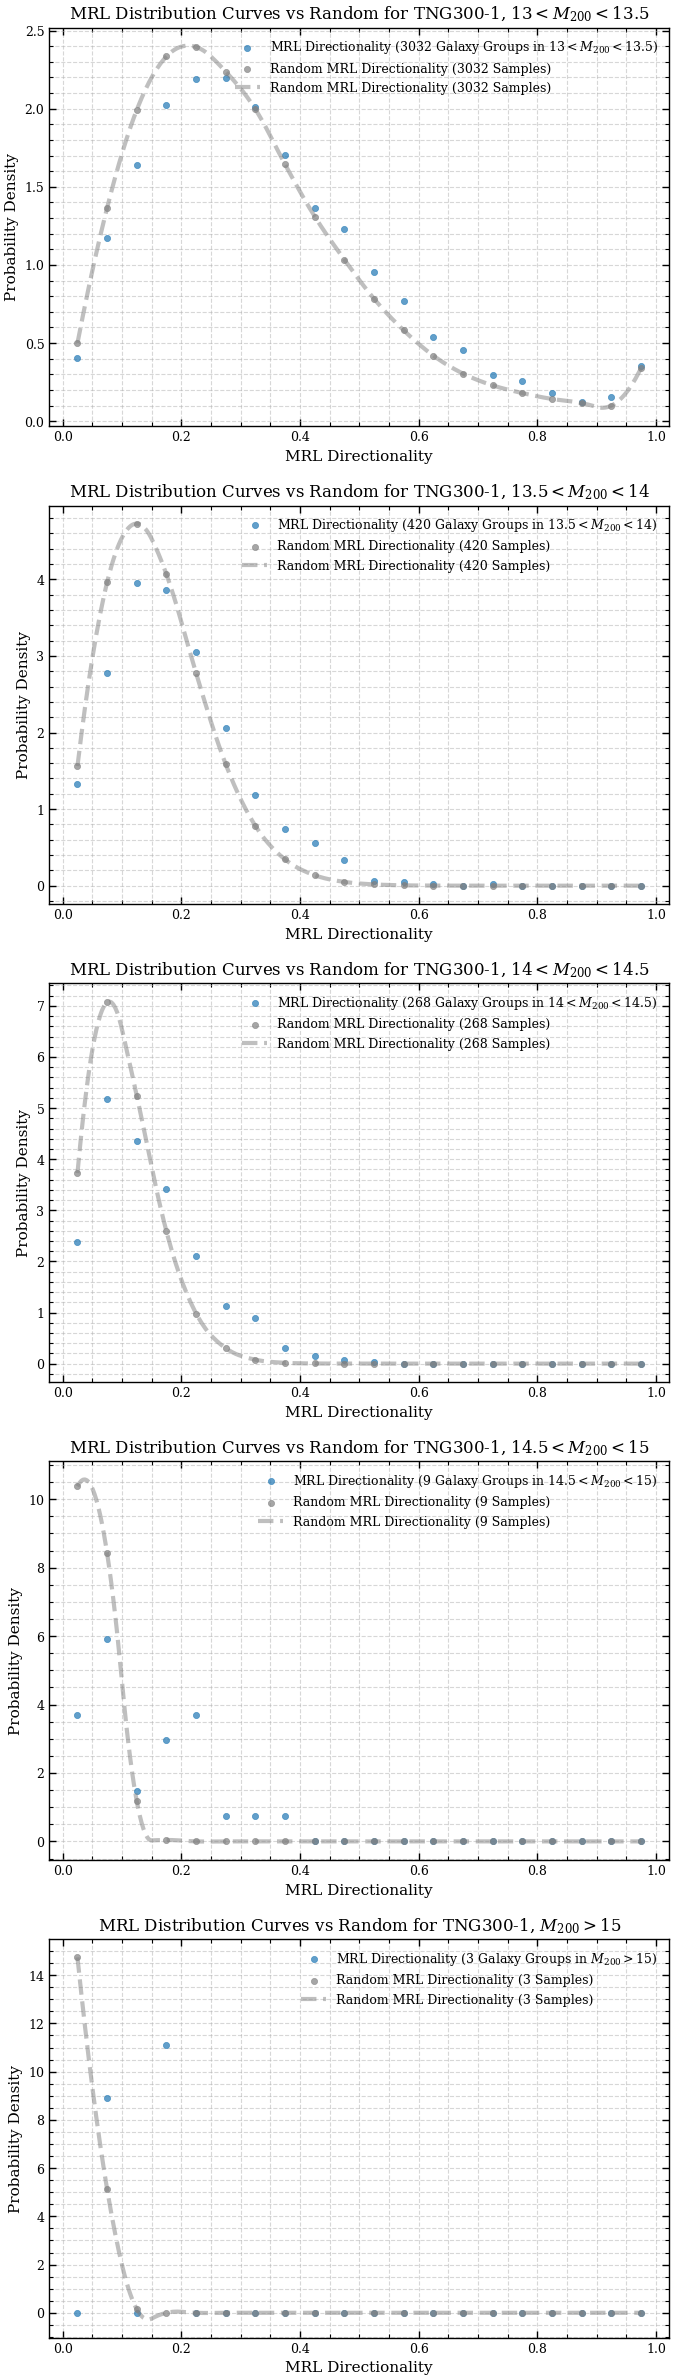

In [30]:
#compute for each group (13-13.5, 13.5-14, 14-14.5, 14.5-15, >15)
overlayMRLAndMRLRandom([(filtered_13_13p5_list_of_galaxy_groups, '$13<M_{200}<13.5$'), (filtered_13p5_14_list_of_galaxy_groups, '$13.5<M_{200}<14$'), (filtered_14_14p5_list_of_galaxy_groups, '$14<M_{200}<14.5$'), (filtered_14p5_15_list_of_galaxy_groups, '$14.5<M_{200}<15$'), (filtered_gt15_list_of_galaxy_groups, '$M_{200}>15$')])

## checkout high MRL

In [14]:
# read high_MRL_galaxy_groups_13>$M_{200}>13.5$.txt file and get a list of galaxy group IDs with high MRL values
high_MRL_galaxy_group_ids = []
with open(scratchPlotDirc + f'/high_MRL_galaxy_groups_$13<M_{{200}}<13.5$.txt', 'r') as f:
    lines = f.readlines()
    for line in lines[1:]:  # Skip header line
        parts = line.split('\t')
        if len(parts) > 0:
            high_MRL_galaxy_group_ids.append(int(parts[0]))
            
high_MRL_galaxy_groups = []
for gg in filtered_13_13p5_list_of_galaxy_groups.getAllGalaxyGroups():
    if gg.getGroupID() in high_MRL_galaxy_group_ids:
        high_MRL_galaxy_groups.append(gg)
        
high_MRL_list_of_galaxy_groups = ListGalaxyGroup(high_MRL_galaxy_groups)
high_MRL_list_of_galaxy_groups.getNumGalaxyGroups()



206

Total Galaxy Groups to process: 206 with pairs : 2313
Processing Subhalo 2/8 in Galaxy Group ID 1656 with total pairs 28

Progress: Processing Galaxy Group ID 5230 / 206with total pairs 3045Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/high_MRL_pairwise_polar_distribution_TNG300-1.png


(<Figure size 600x450 with 1 Axes>,
 <Axes: title={'center': 'Pairwise Polar Difference Distribution for High MRL Galaxy Groups ($13<M_{200}<13.5$) in TNG300-1'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>)

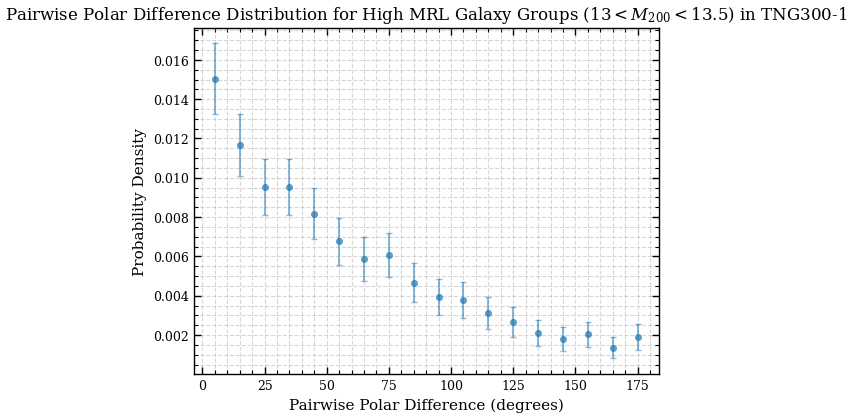

In [19]:
#plot the pairwise polar distribution for these high MRL groups
high_MRL_pairwise_polar_differences = high_MRL_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=False)
high_MRL_pairwise_polar_bins, high_MRL_pairwise_polar_bin_centers, high_MRL_pairwise_polar_errorbars = ListGalaxyGroup.get_histogram_bins(high_MRL_pairwise_polar_differences, bins = np.arange(0, 185, 10), errorbarType='poisson')
high_MRL_polar_plotter = AstroPlotter()
high_MRL_polar_fig, high_MRL_polar_ax = high_MRL_polar_plotter.create_figure()
high_MRL_polar_plotter.scatter_plot(
    high_MRL_pairwise_polar_bin_centers, 
    high_MRL_pairwise_polar_bins,
    errorBars = high_MRL_pairwise_polar_errorbars,
    ax=high_MRL_polar_ax, # Use the same axis for overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Pairwise Polar Difference Distribution for High MRL Galaxy Groups ($13<M_{{200}}<13.5$) in {sim}',
    # ylim = (0, 0.01),
    label="High MRL Galaxy Groups",
    output_filename=scratchPlotDirc + f'/high_MRL_pairwise_polar_distribution_{sim}.png',
    grid=True,
)


In [20]:
#plot <35% R200 and >65% R200 for these high MRL groups
high_MRL_LT35R200_list_of_galaxy_groups = high_MRL_list_of_galaxy_groups.getFilterSubhalos(withinXPercentR200=[0,0.35])
print(high_MRL_LT35R200_list_of_galaxy_groups.getNumGalaxyGroups())
high_MRL_pairwise_polar_differences_inner = high_MRL_LT35R200_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=False)
high_MRL_pairwise_polar_bins_inner, high_MRL_pairwise_polar_bin_centers_inner, high_MRL_pairwise_polar_errorbars_inner = ListGalaxyGroup.get_histogram_bins(high_MRL_pairwise_polar_differences_inner, bins = np.arange(0, 185, 10), errorbarType='poisson')
high_MRL_GT65R200_list_of_galaxy_groups = high_MRL_list_of_galaxy_groups.getFilterSubhalos(withinXPercentR200=[0.65,1])
print(high_MRL_GT65R200_list_of_galaxy_groups.getNumGalaxyGroups())
high_MRL_pairwise_polar_differences_outer = high_MRL_GT65R200_list_of_galaxy_groups.compute_probablity_distribution_of_polar_differences(parallelize=False)
high_MRL_pairwise_polar_bins_outer, high_MRL_pairwise_polar_bin_centers_outer, high_MRL_pairwise_polar_errorbars_outer = ListGalaxyGroup.get_histogram_bins(high_MRL_pairwise_polar_differences_outer, bins = np.arange(0, 185, 10), errorbarType='poisson')
high_MRL_polar_plotter.scatter_plot(
    high_MRL_pairwise_polar_bin_centers_inner, 
    high_MRL_pairwise_polar_bins_inner,
    errorBars = high_MRL_pairwise_polar_errorbars_inner,
    ax=high_MRL_polar_ax, # Use the same axis for overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Pairwise Polar Difference Distribution for High MRL Galaxy Groups ($13<M_{{200}}<13.5$) in {sim}',
    # ylim = (0, 0.01),
    label="High MRL Galaxy Groups (<35% R200)",
    output_filename=None,
    grid=True,
)
high_MRL_polar_plotter.scatter_plot(
    high_MRL_pairwise_polar_bin_centers_outer, 
    high_MRL_pairwise_polar_bins_outer,
    errorBars = high_MRL_pairwise_polar_errorbars_outer,
    ax=high_MRL_polar_ax, # Use the same axis for overlay
    xlabel='Pairwise Polar Difference (degrees)',
    ylabel='Probability Density',
    title=f'Pairwise Polar Difference Distribution for High MRL Galaxy Groups ($13<M_{{200}}<13.5$) in {sim}',
    # ylim = (0, 0.01),
    label="High MRL Galaxy Groups (>65% R200)",
    output_filename=scratchPlotDirc + f'/high_MRL_pairwise_polar_distribution_inner_outer_{sim}.png',
    include_legend=True,
    grid=True,
)

total to process: 206
124gress: Processing Galaxy Group ID 206 / 206
Total Galaxy Groups to process: 124 with pairs : 325
Progress: Processing Galaxy Group ID 1919 / 124with total pairs 1

Progress: Processing Galaxy Group ID 4752 / 124with total pairs 10total to process: 206
150gress: Processing Galaxy Group ID 206 / 206
Total Galaxy Groups to process: 150 with pairs : 492
Progress: Processing Galaxy Group ID 5230 / 150with total pairs 10Figure saved to: /scratch/poulin.al/lopsided/TNG300-1/z0p0/plots/high_MRL_pairwise_polar_distribution_inner_outer_TNG300-1.png


(<Figure size 600x450 with 1 Axes>,
 <Axes: title={'center': 'Pairwise Polar Difference Distribution for High MRL Galaxy Groups ($13<M_{200}<13.5$) in TNG300-1'}, xlabel='Pairwise Polar Difference (degrees)', ylabel='Probability Density'>)

## TBD